# Diseño DSGE Semi-estructural - Jupyter Notebook

## 📋 Estructura por Bloques (Sin Clases)

### **BLOQUE 1: Configuración y Setup**
```python
# Imports y configuración general
# Parámetros del modelo (diccionarios simples)
# Paths y configuración de archivos
# Configuración de matplotlib/warnings

In [1]:
import subprocess
import os

# Cambiar al directorio donde está el archivo .ipynb si es necesario
# os.chdir("ruta/donde/esta/tu/notebook")

# Ejecutar el comando
subprocess.run([
    'jupyter', 'nbconvert', '--to', 'html', 
    'semi-dsge IV.ipynb', 
    '--output', r'C:\Users\Usuario\Downloads\semi-dsge.html'
])

CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', 'semi-dsge IV.ipynb', '--output', 'C:\\Users\\Usuario\\Downloads\\semi-dsge.html'], returncode=4294967295)

In [2]:
# ==========================================
# BLOQUE 1: SETUP Y CONFIGURACIÓN
# ==========================================

# Imports esenciales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import beta, norm, invgamma
import warnings
warnings.filterwarnings('ignore')

print("📦 Librerías cargadas correctamente")

# ==========================================
# CONFIGURACIÓN DE ARCHIVOS
# ==========================================

# Paths de datos (ajustar según tu estructura)
data_paths = {
    'crudo': '../data/raw/crudo.csv',
    'diarias': '../data/raw/series_diarias.xlsx', 
    'mensuales': '../data/raw/series_mensuales.xlsx',
    'trimestrales': '../data/raw/series_trimestrales.xlsx',
    'potencial': '../data/raw/pib_potencial_espana.csv'
}

print("📁 Paths configurados")

# ==========================================
# PARÁMETROS DEL MODELO
# ==========================================

# Parámetros estructurales (valores iniciales para estimación)
# PARÁMETROS AJUSTADOS PARA ESPAÑA
params = {
    # CURVA IS (menos persistencia, más sensibilidad externa por ser economía europea)
    'is_alpha_1': 0.35,    # ↓ Menos persistencia que Chile
    'is_alpha_2': 0.15,    # ↓ Menos inercia
    'is_alpha_3': 0.25,    # ↑ Más sensibilidad tipos (eurozona)
    'is_alpha_4': 0.30,    # ↑ MÁS sensibilidad UE (principal socio)
    'is_alpha_5': 0.05,    # ↓ Menos sensibilidad EEUU
    'is_alpha_6': -0.05,   # ↓ Menos sensibilidad tipo cambio (euro)
    'is_alpha_7': 0.03,    # ↓ Menos sensibilidad petróleo
    
    # PHILLIPS CURVE (menos volatile que Chile)
    'alpha_1': 0.40,       # ↑ Más persistencia inflación (eurozona)
    'alpha_2': 0.20,       # ↓ Menos sensibilidad brecha
    'alpha_3': 0.10,       # ↓ Menos sensibilidad tipo cambio
    'alpha_4': 0.25,       # ↑ Más influencia inflación externa
    
    # Resto igual...
    'beta_1': 0.15,
    'beta_2': 0.10, 
    'beta_3': 0.45,
    'beta_4': 0.30,
    'gamma_1': 0.85,
    'gamma_2': 1.65,
    'gamma_3': 0.18,
    'theta': 0.30,
    'delta_1': 0.25,
    'delta_2': 0.40,
    'tau_1': 0.35,
    'tau_2': 0.85,
    'tau_4': 0.05,
    'weight_core': 0.70,
    'weight_nt_in_core': 0.65,
    'weight_food': 0.20,
    'weight_energy': 0.10,
    'beta_energy_oil': 0.25,
    'rho_demand': 0.60,
    'rho_cost_nt': 0.40,
    'rho_cost_t': 0.30,
    'rho_monetary': 0.25,
    'rho_uip': 0.70,
    'rho_unemployment': 0.50
}

print(f"⚙️  Parámetros inicializados: {len(params)} parámetros")

# ==========================================
# PRIORS BAYESIANOS
# ==========================================

priors = {
    # Curva IS
    'is_alpha_1': {'dist': 'beta', 'mean': 0.50, 'std': 0.10},
    'is_alpha_2': {'dist': 'beta', 'mean': 0.25, 'std': 0.08},
    'is_alpha_3': {'dist': 'beta', 'mean': 0.20, 'std': 0.06},
    'is_alpha_4': {'dist': 'beta', 'mean': 0.15, 'std': 0.05},
    'is_alpha_5': {'dist': 'beta', 'mean': 0.10, 'std': 0.04},
    'is_alpha_6': {'dist': 'norm', 'mean': -0.10, 'std': 0.05},
    'is_alpha_7': {'dist': 'beta', 'mean': 0.05, 'std': 0.03},
    
    # Phillips Curve NT
    'alpha_1': {'dist': 'beta', 'mean': 0.25, 'std': 0.08},
    'alpha_2': {'dist': 'beta', 'mean': 0.30, 'std': 0.10},
    'alpha_3': {'dist': 'beta', 'mean': 0.15, 'std': 0.06},
    'alpha_4': {'dist': 'beta', 'mean': 0.20, 'std': 0.08},
    
    # Phillips Curve T
    'beta_1': {'dist': 'beta', 'mean': 0.15, 'std': 0.06},
    'beta_2': {'dist': 'beta', 'mean': 0.10, 'std': 0.05},
    'beta_3': {'dist': 'beta', 'mean': 0.45, 'std': 0.12},
    'beta_4': {'dist': 'beta', 'mean': 0.30, 'std': 0.10},
    
    # Taylor Rule
    'gamma_1': {'dist': 'beta', 'mean': 0.85, 'std': 0.06},
    'gamma_2': {'dist': 'norm', 'mean': 1.65, 'std': 0.20},
    'gamma_3': {'dist': 'beta', 'mean': 0.18, 'std': 0.06},
    
    # UIP
    'theta': {'dist': 'beta', 'mean': 0.30, 'std': 0.10},
    'delta_1': {'dist': 'beta', 'mean': 0.25, 'std': 0.08},
    'delta_2': {'dist': 'beta', 'mean': 0.40, 'std': 0.12},
    
    # Okun
    'tau_1': {'dist': 'beta', 'mean': 0.35, 'std': 0.08},
    'tau_2': {'dist': 'beta', 'mean': 0.85, 'std': 0.06},
    'tau_4': {'dist': 'beta', 'mean': 0.05, 'std': 0.02},
    
    # Pesos
    'weight_core': {'dist': 'beta', 'mean': 0.70, 'std': 0.04},
    'weight_nt_in_core': {'dist': 'beta', 'mean': 0.65, 'std': 0.05},
    'weight_food': {'dist': 'beta', 'mean': 0.20, 'std': 0.03},
    'weight_energy': {'dist': 'beta', 'mean': 0.10, 'std': 0.02},
    'beta_energy_oil': {'dist': 'beta', 'mean': 0.25, 'std': 0.08},
    
    # Persistencia
    'rho_demand': {'dist': 'beta', 'mean': 0.60, 'std': 0.15},
    'rho_cost_nt': {'dist': 'beta', 'mean': 0.40, 'std': 0.12},
    'rho_cost_t': {'dist': 'beta', 'mean': 0.30, 'std': 0.10},
    'rho_monetary': {'dist': 'beta', 'mean': 0.25, 'std': 0.10},
    'rho_uip': {'dist': 'beta', 'mean': 0.70, 'std': 0.10},
    'rho_unemployment': {'dist': 'beta', 'mean': 0.50, 'std': 0.15}
}

print(f"📊 Priors configurados: {len(priors)} distribuciones")

# ==========================================
# VARIANZAS DE SHOCKS (valores iniciales)
# ==========================================

shock_variances = {
    'sigma_demand': 0.008,
    'sigma_cost_nt_persistent': 0.003,
    'sigma_cost_nt_transitory': 0.002,
    'sigma_cost_t_persistent': 0.004,
    'sigma_cost_t_transitory': 0.002,
    'sigma_monetary': 0.005,
    'sigma_uip': 0.012,
    'sigma_unemployment': 0.013,
    'sigma_food': 0.011,
    'sigma_energy': 0.015
}

print(f"📈 Varianzas de shocks: {len(shock_variances)} tipos")

# ==========================================
# CONFIGURACIÓN MATPLOTLIB
# ==========================================

plt.style.use('default')
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})

print("🎨 Matplotlib configurado")

# ==========================================
# VERIFICACIÓN FINAL
# ==========================================

print("\n" + "="*50)
print("✅ BLOQUE 1 COMPLETADO")
print("="*50)
print(f"📋 Resumen:")
print(f"   • Parámetros modelo: {len(params)}")
print(f"   • Priors bayesianos: {len(priors)}")
print(f"   • Varianzas shocks: {len(shock_variances)}")
print(f"   • Archivos datos: {len(data_paths)}")
print("="*50)

c:\Users\Usuario\anaconda3\envs\tftimeseriesII\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
c:\Users\Usuario\anaconda3\envs\tftimeseriesII\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
c:\Users\Usuario\anaconda3\envs\tftimeseriesII\lib\site-packages\numpy\.libs\libopenblas.XWYDX2IKJW2NMTWSFYNGFUWKQU3LYTCZ.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


📦 Librerías cargadas correctamente
📁 Paths configurados
⚙️  Parámetros inicializados: 35 parámetros
📊 Priors configurados: 35 distribuciones
📈 Varianzas de shocks: 10 tipos
🎨 Matplotlib configurado

✅ BLOQUE 1 COMPLETADO
📋 Resumen:
   • Parámetros modelo: 35
   • Priors bayesianos: 35
   • Varianzas shocks: 10
   • Archivos datos: 5



### **BLOQUE 2: Carga y Limpieza de Datos**
```python
# Funciones de carga de datos
# Limpieza y transformación básica
# Validación rápida de datos
# Merge de datasets

In [3]:
# ==========================================
# BLOQUE 2: CARGA Y LIMPIEZA DE DATOS
# ==========================================

def load_potential_gdp_data():
    """
    Cargar estimaciones del PIB potencial español desde archivo CSV
    """
    print("📊 Cargando estimaciones PIB potencial español...")
    
    try:
        # Cargar archivo CSV con estimaciones del PIB potencial
        potential_data = pd.read_csv('../data/raw/pib_potencial_espana.csv', sep=";", encoding='utf-8-sig')
        
        print(f"✅ Datos cargados: {len(potential_data)} observaciones")
        print(f"📅 Período: {potential_data['date'].iloc[0]} a {potential_data['date'].iloc[-1]}")
        
        # Verificar columnas requeridas
        required_cols = ['date', 'gdp_real', 'gdp_potential', 'output_gap', 
                        'potential_growth', 'tfp_trend', 'tfp_cycle', 'nairu', 
                        'employment_potential']
        
        missing_cols = [col for col in required_cols if col not in potential_data.columns]
        if missing_cols:
            print(f"⚠️ Columnas faltantes: {missing_cols}")
            return None
            
        # Convertir fechas
        potential_data['date'] = pd.to_datetime(potential_data['date'])
        potential_data.set_index('date', inplace=True)
        
        # Estadísticas básicas
        print(f"📊 PIB potencial actual: {potential_data['gdp_potential'].iloc[-1]:.0f}")
        print(f"📊 Brecha producto actual: {potential_data['output_gap'].iloc[-1]:.2f}%")
        print(f"📊 NAIRU actual: {potential_data['nairu'].iloc[-1]:.1f}%")
        
        return potential_data
        
    except Exception as e:
        print(f"❌ Error cargando PIB potencial: {e}")
        return None
    
    
def load_and_process_data():
    """Carga y procesa todos los datos siguiendo tu metodología original"""
    
    print("🔄 Cargando archivos...")
    
    # Cargar archivos
    try:
        df_crudo = pd.read_csv(data_paths['crudo'])
        df_diarias = pd.read_excel(data_paths['diarias'])
        df_mensuales = pd.read_excel(data_paths['mensuales'])
        df_trimestrales = pd.read_excel(data_paths['trimestrales'])
        print("✅ Archivos cargados correctamente")
    except FileNotFoundError as e:
        print(f"❌ Error: No se encontró {e.filename}")
        return None
    
    print("🧹 Limpiando datos...")
    
    # Limpiar datos (eliminar segunda fila)
    df_diarias = df_diarias.drop(df_diarias.index[0]).reset_index(drop=True)
    df_mensuales = df_mensuales.drop(df_mensuales.index[0]).reset_index(drop=True)
    df_trimestrales = df_trimestrales.drop(df_trimestrales.index[0]).reset_index(drop=True)
    
    # Procesar crudo
    df_crudo.rename(columns={'observation_date': 'Fecha', 'DCOILBRENTEU': 'Petroleo_Brent_crudo'}, inplace=True)
    df_crudo['Fecha'] = pd.to_datetime(df_crudo['Fecha'], errors='coerce')
    df_crudo.set_index('Fecha', inplace=True)
    df_crudo['Petroleo_Brent_crudo'] = pd.to_numeric(df_crudo['Petroleo_Brent_crudo'], errors='coerce')
    df_crudo_q = df_crudo.resample('Q').mean()
    df_crudo_q.index = df_crudo_q.index.year.astype(str) + '0' + df_crudo_q.index.quarter.astype(str)
    
    print("🔗 Procesando fechas y merge...")
    
    # Preparar DataFrames
    df_diarias.columns = ['Fecha', 'Tipo_Cambio']
    df_mensuales.rename(columns={'SERIES': 'Fecha'}, inplace=True)
    df_trimestrales.rename(columns={'SERIES': 'Fecha'}, inplace=True)
    
    # Convertir fechas
    df_diarias['Fecha'] = pd.to_datetime(df_diarias['Fecha'], format='%Y%m%d')
    df_mensuales['Fecha'] = pd.to_datetime(df_mensuales['Fecha'], format='%Y%m')
    df_trimestrales['Fecha'] = pd.to_datetime(df_trimestrales['Fecha'], format='%Y%m')
    
    # Preparar datos
    df_diarias['Tipo_Cambio'] = df_diarias['Tipo_Cambio'].astype(float)
    df_diarias.set_index('Fecha', inplace=True)
    df_mensuales.set_index('Fecha', inplace=True)
    df_trimestrales.set_index('Fecha', inplace=True)
    
    # Limpiar valores
    df_mensuales.replace('-', np.nan, inplace=True)
    df_trimestrales.replace('-', np.nan, inplace=True)
    
    # Convertir a trimestral
    df_trimestral_diario = df_diarias.resample('Q').mean()
    df_trimestral_diario.index = df_trimestral_diario.index.year.astype(str) + '0' + df_trimestral_diario.index.quarter.astype(str)
    
    df_trimestral_mensual = df_mensuales.resample('Q').mean()
    df_trimestral_mensual.index = df_trimestral_mensual.index.year.astype(str) + '0' + df_trimestral_mensual.index.quarter.astype(str)
    
    df_trimestrales.index = df_trimestrales.index.strftime('%Y%m')
    
    # Merge paso a paso
    df_intermedio = pd.merge(df_trimestral_diario, df_trimestral_mensual, 
                           left_index=True, right_index=True, how='outer')
    
    df_intermedio = pd.merge(df_intermedio, df_crudo_q, 
                           left_index=True, right_index=True, how='outer')
    
    df_final = pd.merge(df_intermedio, df_trimestrales, 
                       left_index=True, right_index=True, how='outer')
    
    #Integrar datos PIB potencial
    print("🔗 Integrando datos PIB potencial...")
    potential_data = load_potential_gdp_data()
    
    if potential_data is not None:
        # Convertir índices para merge
        # df_final usa formato 'YYYY0Q', potential_data usa datetime
        potential_data_indexed = potential_data.copy()
        potential_data_indexed.index = potential_data_indexed.index.year.astype(str) + '0' + potential_data_indexed.index.quarter.astype(str)
        
        # Merge con datos principales
        df_final = pd.merge(df_final, potential_data_indexed, 
                           left_index=True, right_index=True, how='outer')
        
        print(f"✅ PIB potencial integrado: {len(potential_data_indexed)} observaciones")
    else:
        print("⚠️ No se pudieron cargar datos PIB potencial")

    return df_final

def identify_variables(df):
    """Identifica variables disponibles en el dataset"""
    
    print("🔍 Identificando variables...")
    
    # Mapeo basado en tu código original y datos disponibles
    var_mapping = {}
    
    # Buscar variables por nombre
    for col in df.columns:
        col_lower = col.lower()
        
        # Variables económicas principales
        if 'pib' in col_lower and 'volumen' in col_lower and 'alemania' not in col_lower and 'eeuu' not in col_lower and 'ue' not in col_lower:
            var_mapping['gdp_real_spain'] = col
        elif 'unemployment' in col_lower or 'paro' in col_lower:
            var_mapping['unemployment_rate'] = col
        elif 'tipo_cambio' in col_lower or 'exchange' in col_lower:
            var_mapping['exchange_rate'] = col
        elif 'petroleo' in col_lower or 'oil' in col_lower or 'brent' in col_lower:
            var_mapping['oil_price'] = col
        elif 'consumo' in col_lower and 'hogares' in col_lower:
            var_mapping['consumption'] = col
        elif 'formacion' in col_lower and 'capital' in col_lower:
            var_mapping['investment'] = col
        elif 'exportacion' in col_lower:
            var_mapping['exports'] = col
        elif 'importacion' in col_lower:
            var_mapping['imports'] = col
        elif 'ipc' in col_lower:
            if 'general' in col_lower and 'subyacente' not in col_lower:
                var_mapping['inflation_total'] = col
            elif 'subyacente' in col_lower:
                var_mapping['inflation_core'] = col
            elif 'alimentos' in col_lower:
                var_mapping['inflation_food'] = col
            elif 'energeticos' in col_lower:
                var_mapping['inflation_energy'] = col
            elif 'servicios' in col_lower:
                var_mapping['inflation_services'] = col
            elif 'bienes industriales' in col_lower:
                var_mapping['inflation_goods'] = col
            elif 'eeuu' in col_lower:
                var_mapping['inflation_usa'] = col
        elif 'ipca' in col_lower and 'ue' in col_lower:
            var_mapping['inflation_eu'] = col
        elif 'rendimiento' in col_lower and 'bono' in col_lower:
            if 'alemania' in col_lower:
                var_mapping['interest_rate_germany'] = col
            elif 'eeuu' in col_lower:
                var_mapping['interest_rate_usa'] = col
        elif 'TIPO INTERES' in col and 'LETRAS DEL TESORO' in col:
            var_mapping['interest_rate_spain'] = col
    
    # PIBs externos
    for col in df.columns:
        if 'PIB' in col and 'ALEMANIA' in col:
            var_mapping['gdp_germany'] = col
        elif 'PIB' in col and 'EEUU' in col:
            var_mapping['gdp_usa'] = col
        elif 'PIB' in col and 'UE' in col:
            var_mapping['gdp_eu'] = col
    
    print(f"📊 Variables identificadas: {len(var_mapping)}")
    for var, col in var_mapping.items():
        print(f"   • {var}: {col}")
    
    # Variables críticas faltantes
    critical_vars = ['inflation_total', 'inflation_core', 'interest_rate']
    missing_critical = [var for var in critical_vars if var not in var_mapping]
    
    if missing_critical:
        print(f"\n🚨 Variables críticas faltantes: {missing_critical}")
        print("   💡 Necesitas datos de inflación y tipos de interés para el modelo DSGE")
    
    # DIAGNÓSTICO: Verificar todas las columnas del dataset
    print(f"\n🔍 DIAGNÓSTICO - Columnas en dataset:")
    potential_cols_in_df = [col for col in df.columns if col in ['gdp_real', 'gdp_potential', 'output_gap', 'potential_growth', 'tfp_trend', 'tfp_cycle', 'nairu', 'employment_potential']]
    print(f"   Variables PIB potencial en dataset: {potential_cols_in_df}")
    
    # Variables del PIB potencial (MAPEO CORREGIDO)
    if 'output_gap' in df.columns:
        var_mapping['output_gap_spain'] = 'output_gap'
        print("✅ Brecha producto España: output_gap")
    
    if 'gdp_potential' in df.columns:
        var_mapping['gdp_potential_spain'] = 'gdp_potential'
        print("✅ PIB potencial España: gdp_potential")
    
    if 'potential_growth' in df.columns:
        var_mapping['potential_growth_spain'] = 'potential_growth'
        print("✅ Crecimiento potencial España: potential_growth")
    
    if 'nairu' in df.columns:
        var_mapping['nairu_spain'] = 'nairu'  # ← CORREGIDO
        print("✅ NAIRU España: nairu")
    
    if 'tfp_trend' in df.columns:
        var_mapping['tfp_trend_spain'] = 'tfp_trend'
        print("✅ TFP tendencial España: tfp_trend")
    
    if 'tfp_cycle' in df.columns:
        var_mapping['tfp_cycle_spain'] = 'tfp_cycle'
        print("✅ TFP ciclo España: tfp_cycle")
    
    if 'employment_potential' in df.columns:
        var_mapping['employment_potential_spain'] = 'employment_potential'
        print("✅ Empleo potencial España: employment_potential")
    
    if 'gdp_real' in df.columns:
        # Solo si no existe ya una variable de PIB real España
        if 'gdp_real_spain' not in var_mapping:
            var_mapping['gdp_real_spain'] = 'gdp_real'
            print("✅ PIB real España: gdp_real (del modelo potencial)")

    return var_mapping

# ==========================================
# EJECUTAR CARGA Y PROCESAMIENTO
# ==========================================

print("🔄 Iniciando carga y procesamiento de datos...")

# Cargar y procesar datos
df_final = load_and_process_data()

if df_final is not None:
    # Identificar variables
    var_mapping = identify_variables(df_final)
    
    # Información del dataset
    print("\n" + "="*50)
    print("✅ BLOQUE 2 COMPLETADO")
    print("="*50)
    print(f"📈 Dataset final:")
    print(f"   • Observaciones: {df_final.shape[0]}")
    print(f"   • Variables: {df_final.shape[1]}")
    print(f"   • Variables identificadas: {len(var_mapping)}")
    print(f"   • Período índice: {df_final.index[0]} a {df_final.index[-1]}")
    print("="*50)
    
    # Mostrar primeras filas para verificar
    print("\n📋 Primeras 3 observaciones:")
    print(df_final.head(3))
    
else:
    print("❌ Error en procesamiento de datos")

🔄 Iniciando carga y procesamiento de datos...
🔄 Cargando archivos...
✅ Archivos cargados correctamente
🧹 Limpiando datos...
🔗 Procesando fechas y merge...
🔗 Integrando datos PIB potencial...
📊 Cargando estimaciones PIB potencial español...
✅ Datos cargados: 109 observaciones
📅 Período: 2000-01-01 a 2027-01-01
📊 PIB potencial actual: 312996
📊 Brecha producto actual: nan%
📊 NAIRU actual: 12.1%
✅ PIB potencial integrado: 109 observaciones
🔍 Identificando variables...
📊 Variables identificadas: 21
   • exchange_rate: Tipo_Cambio
   • inflation_total: IPC. GENERAL
   • inflation_food: IPC. ALIMENTOS CON ELABORACION, BEBIDAS Y TABACO
   • inflation_goods: IPC. BIENES INDUSTRIALES
   • inflation_services: IPC. SERVICIOS, SIN ALQUILER DE VIVIENDA
   • inflation_energy: IPC. PRODUCTOS ENERGETICOS
   • inflation_core: IPC. SUBYACENTE (GENERAL SIN ALIMENTOS NO ELABORADOS NI PRODUCTOS ENERGETICOS)
   • inflation_usa: IPC. EEUU
   • interest_rate_spain: TIPO INTERES. MERCADO PRIMARIO. LETRAS DEL TE

### **BLOQUE 3: Preparación de Variables**
```python
# Cálculo de brechas de producto (HP filter)
# Componentes de inflación
# Variables financieras y externas
# Array final para estimación

In [4]:
# ==========================================
# BLOQUE 3: PREPARACIÓN DE VARIABLES
# ==========================================

from scipy.signal import filtfilt

def hp_filter(y, lamb=1600):
    """Filtro Hodrick-Prescott para extraer tendencia y ciclo"""
    
    # Eliminar NaN y mantener índices
    y_clean = y.dropna()
    if len(y_clean) < 10:
        print("⚠️  Pocos datos válidos para HP filter")
        return pd.Series(index=y.index, dtype=float), pd.Series(index=y.index, dtype=float)
    
    T = len(y_clean)
    
    # Matriz para HP filter
    K = np.zeros((T-2, T))
    for i in range(T-2):
        K[i, i] = lamb
        K[i, i+1] = -2*lamb
        K[i, i+2] = lamb
    
    # Matriz identidad + K'K
    I = np.eye(T)
    A = I + K.T @ K
    
    # Tendencia = (I + λK'K)^(-1) * y
    try:
        trend_values = np.linalg.solve(A, y_clean.values)
        trend = pd.Series(trend_values, index=y_clean.index)
        
        # Expandir a serie original con NaN donde corresponde
        trend_full = pd.Series(index=y.index, dtype=float)
        trend_full.loc[y_clean.index] = trend
        
        # Ciclo = serie original - tendencia
        cycle_full = y - trend_full
        
        return trend_full, cycle_full
        
    except np.linalg.LinAlgError:
        print("⚠️  Error en HP filter - usando tendencia lineal")
        # Fallback: tendencia lineal
        trend_full = pd.Series(index=y.index, dtype=float)
        if len(y_clean) > 1:
            trend_values = np.linspace(y_clean.iloc[0], y_clean.iloc[-1], len(y_clean))
            trend_full.loc[y_clean.index] = trend_values
        cycle_full = y - trend_full
        return trend_full, cycle_full

def calculate_output_gaps():
    """Usa brechas de producto del archivo PIB potencial (España) y calcula externas"""
    print("📊 Cargando brechas de producto...")
    gaps = {}
    
    # ESPAÑA: Usar estimaciones del PIB potencial (no calcular)
    if 'output_gap_spain' in var_mapping:
        gaps['output_gap_spain'] = df_final[var_mapping['output_gap_spain']]
        print(f"✅ Brecha PIB España (del archivo PIB potencial): {gaps['output_gap_spain'].count()} observaciones")
    
    if 'gdp_potential_spain' in var_mapping:
        gaps['gdp_potential_spain'] = df_final[var_mapping['gdp_potential_spain']]
        print(f"✅ PIB potencial España (del archivo): {gaps['gdp_potential_spain'].count()} observaciones")
    
    # PAÍSES EXTERNOS: Mantener cálculo con HP filter (como estaba)
    external_countries = [
        ('eu', 'gdp_eu', 'UE'),
        ('usa', 'gdp_usa', 'EEUU'), 
        ('germany', 'gdp_germany', 'Alemania')
    ]
    
    for country_code, var_key, country_name in external_countries:
        if var_key in var_mapping:
            gdp_col = var_mapping[var_key]
            gdp_series_raw = df_final[gdp_col].dropna()
            
            if len(gdp_series_raw) > 0:
                print(f"🔍 Procesando PIB {country_name}:")
                print(f"   • Serie original (rango): {gdp_series_raw.min():.0f} - {gdp_series_raw.max():.0f}")
                
                # CORRECCIÓN AUTOMÁTICA: Si media > 1000 → convertir a índice base 100
                if gdp_series_raw.mean() > 1000:
                    print(f"   🔧 CORRIGIENDO: niveles absolutos → índice base 100")
                    base_value = gdp_series_raw.iloc[0]
                    gdp_series_normalized = (gdp_series_raw / base_value) * 100
                    gdp_series_full = pd.Series(index=df_final.index, dtype=float)
                    gdp_series_full.loc[gdp_series_raw.index] = gdp_series_normalized
                    gdp_series = gdp_series_full
                    print(f"   ✅ Serie normalizada (rango): {gdp_series_normalized.min():.1f} - {gdp_series_normalized.max():.1f}")
                else:
                    print(f"   ✅ Ya en formato correcto (índice)")
                    gdp_series = df_final[gdp_col]
                
                # Aplicar HP filter SOLO para países externos
                trend, cycle = hp_filter(gdp_series)
                gaps[f'output_gap_{country_code}'] = cycle
                gaps[f'gdp_potential_{country_code}'] = trend
                
                cycle_clean = cycle.dropna()
                if len(cycle_clean) > 0:
                    print(f"   📊 Brecha {country_name} (últimos 3): {cycle_clean.tail(3).values}")
                
                print(f"✅ Brecha PIB {country_name} calculada ({cycle.count()} observaciones)")
    
    return gaps

def prepare_inflation_components():
   """Prepara componentes de inflación - CONVERTIDOS A TASAS INTERANUALES"""
   
   print("📈 Preparando componentes de inflación...")
   
   inflation_data = {}
   
   # Función auxiliar para convertir índice a tasa interanual
   def index_to_inflation_rate(index_series, var_name):
       """Convierte índice de precios a tasa de inflación interanual (%)"""
       if index_series is None or len(index_series) < 4:
           print(f"⚠️ {var_name}: Datos insuficientes para calcular tasa interanual")
           return pd.Series(dtype=float)
       
       # Tasa interanual = ((IPC_t / IPC_t-4) - 1) * 100
       inflation_rate = index_series.pct_change(periods=4) * 100
       
       # Información de la transformación
       valid_obs = inflation_rate.count()
       print(f"   • {var_name}: {valid_obs} observaciones de tasa interanual")
       
       return inflation_rate
   
   # Inflación total y core
   if 'inflation_total' in var_mapping:
       ipc_total = df_final[var_mapping['inflation_total']]
       inflation_data['inflation_total'] = index_to_inflation_rate(ipc_total, 'Inflación Total')
       
   if 'inflation_core' in var_mapping:
       ipc_core = df_final[var_mapping['inflation_core']]
       inflation_data['inflation_core'] = index_to_inflation_rate(ipc_core, 'Inflación Core')
   
   # Componentes específicos españoles
   inflation_components = {
       'inflation_food': 'inflation_food',
       'inflation_energy': 'inflation_energy', 
       'inflation_services': 'inflation_services',
       'inflation_goods': 'inflation_goods'
   }
   
   for comp_name, var_key in inflation_components.items():
       if var_key in var_mapping:
           ipc_component = df_final[var_mapping[var_key]]
           inflation_data[comp_name] = index_to_inflation_rate(ipc_component, comp_name.replace('_', ' ').title())
   
   # Inflación externa (proxy) - TAMBIÉN CONVERTIR A TASAS
   if 'inflation_usa' in var_mapping:
       ipc_usa = df_final[var_mapping['inflation_usa']]
       inflation_data['inflation_external'] = index_to_inflation_rate(ipc_usa, 'Inflación EEUU')
       # También crear variable específica USA
       inflation_data['inflation_usa'] = inflation_data['inflation_external'].copy()
       
   elif 'inflation_eu' in var_mapping:
       ipc_eu = df_final[var_mapping['inflation_eu']]
       inflation_data['inflation_external'] = index_to_inflation_rate(ipc_eu, 'Inflación UE')
       # También crear variable específica UE
       inflation_data['inflation_eu'] = inflation_data['inflation_external'].copy()
   
   # Crear inflación core tradable/no-tradable (aproximación)
   if 'inflation_goods' in inflation_data and 'inflation_services' in inflation_data:
       # No-tradable ≈ servicios (ya convertidos a tasas)
       inflation_data['inflation_core_nt'] = inflation_data['inflation_services'].copy()
       # Tradable ≈ bienes industriales (ya convertidos a tasas)
       inflation_data['inflation_core_t'] = inflation_data['inflation_goods'].copy()
       print("✅ Componentes tradable/no-tradable creados (en tasas %)")
   
   # Información final
   print(f"✅ {len(inflation_data)} componentes de inflación preparados")
   print("📊 Resumen conversión índices → tasas interanuales:")
   
   # Mostrar estadísticas básicas de las tasas convertidas
   key_inflation_vars = ['inflation_total', 'inflation_core', 'inflation_external']
   for var in key_inflation_vars:
       if var in inflation_data:
           series = inflation_data[var]
           if len(series.dropna()) > 0:
               mean_rate = series.mean()
               std_rate = series.std()
               print(f"   • {var}: Media={mean_rate:.2f}%, Desv={std_rate:.2f}%")
   
   return inflation_data

def prepare_financial_variables():
    """Prepara variables financieras"""
    
    print("💰 Preparando variables financieras...")
    
    financial_data = {}
    
    # Tipos de interés
    if 'interest_rate_spain' in var_mapping:
        financial_data['interest_rate_spain'] = df_final[var_mapping['interest_rate_spain']]
    if 'interest_rate_germany' in var_mapping:
        financial_data['interest_rate_germany'] = df_final[var_mapping['interest_rate_germany']]
    if 'interest_rate_usa' in var_mapping:
        financial_data['interest_rate_usa'] = df_final[var_mapping['interest_rate_usa']]
    
    # Prima de riesgo (España vs Alemania)
    if 'interest_rate_spain' in financial_data and 'interest_rate_germany' in financial_data:
        spain_10y = financial_data.get('interest_rate_spain', financial_data['interest_rate_spain'])
        germany_10y = financial_data['interest_rate_germany']
        financial_data['risk_premium'] = spain_10y - germany_10y
        print("✅ Prima de riesgo calculada")
    
    # Tipo de cambio
    if 'exchange_rate' in var_mapping:
        financial_data['exchange_rate'] = df_final[var_mapping['exchange_rate']]
        
        # Tipo de cambio real (ajustado por inflación si disponible)
        if 'inflation_total' in var_mapping and 'inflation_usa' in var_mapping:
            inflation_esp = df_final[var_mapping['inflation_total']]
            inflation_usa = df_final[var_mapping['inflation_usa']]
            # TCR = TC nominal * (P_usa / P_esp)
            financial_data['real_exchange_rate'] = (financial_data['exchange_rate'] * 
                                                  (1 + inflation_usa/100) / (1 + inflation_esp/100))
            print("✅ Tipo de cambio real calculado")
        else:
            financial_data['real_exchange_rate'] = financial_data['exchange_rate']
    
    print(f"✅ {len(financial_data)} variables financieras preparadas")
    return financial_data

def prepare_external_variables():
    """Prepara variables externas"""
    
    print("🌍 Preparando variables externas...")
    
    external_data = {}
    
    # PIBs externos (ya en niveles)
    if 'gdp_usa' in var_mapping:
        external_data['gdp_world'] = df_final[var_mapping['gdp_usa']]  # USA como proxy mundo
    if 'gdp_eu' in var_mapping:
        external_data['gdp_eu'] = df_final[var_mapping['gdp_eu']]
    if 'gdp_germany' in var_mapping:
        external_data['gdp_germany'] = df_final[var_mapping['gdp_germany']]
    
    # Precio del petróleo
    if 'oil_price' in var_mapping:
        external_data['oil_price'] = df_final[var_mapping['oil_price']]
    
    print(f"✅ {len(external_data)} variables externas preparadas")
    return external_data

def prepare_domestic_variables():
    """Prepara variables domésticas"""
    
    print("🏠 Preparando variables domésticas...")
    
    domestic_data = {}
    
    # Desempleo
    if 'unemployment_rate' in var_mapping:
        domestic_data['unemployment_rate'] = df_final[var_mapping['unemployment_rate']]
    
    # Componentes de demanda
    demand_components = {
        'consumption': 'consumption',
        'investment': 'investment', 
        'exports': 'exports',
        'imports': 'imports'
    }
    
    for comp_name, var_key in demand_components.items():
        if var_key in var_mapping:
            domestic_data[comp_name] = df_final[var_mapping[var_key]]
    
    print(f"✅ {len(domestic_data)} variables domésticas preparadas")
    return domestic_data

def create_estimation_dataset():
    """Crea dataset final para estimación con todas las variables"""
    
    print("🔧 Creando dataset de estimación...")
    
    # Recopilar todas las variables preparadas
    all_data = {}
    
    # Brechas de producto
    gaps = calculate_output_gaps()
    all_data.update(gaps)
    
    # Inflación
    inflation = prepare_inflation_components()
    all_data.update(inflation)
    
    # Variables financieras
    financial = prepare_financial_variables()
    all_data.update(financial)
    
    # Variables externas
    external = prepare_external_variables()
    all_data.update(external)
    
    # Variables domésticas
    domestic = prepare_domestic_variables()
    all_data.update(domestic)

    # Añadir variables directas del archivo PIB potencial
    print("📊 Añadiendo variables directas del archivo PIB potencial...")
    if 'nairu' in df_final.columns:
        all_data['nairu_spain'] = df_final['nairu']
        print("   ✅ NAIRU añadida")
    
    if 'potential_growth' in df_final.columns:
        all_data['potential_growth_spain'] = df_final['potential_growth']
        print("   ✅ Crecimiento potencial añadido")
    
    if 'tfp_trend' in df_final.columns:
        all_data['tfp_trend_spain'] = df_final['tfp_trend']
        print("   ✅ TFP tendencial añadida")
    
    if 'tfp_cycle' in df_final.columns:
        all_data['tfp_cycle_spain'] = df_final['tfp_cycle']
        print("   ✅ TFP ciclo añadida")
    
    if 'employment_potential' in df_final.columns:
        all_data['employment_potential_spain'] = df_final['employment_potential']
        print("   ✅ Empleo potencial añadido")
    
    if 'gdp_real' in df_final.columns:
        all_data['gdp_real'] = df_final['gdp_real']
        print("   ✅ PIB real añadido")
    
    # Crear DataFrame final
    estimation_df = pd.DataFrame(all_data, index=df_final.index)
    
    # Eliminar filas completamente vacías
    estimation_df = estimation_df.dropna(how='all')
    
    # Información sobre disponibilidad de datos
    print(f"\n📋 Dataset de estimación creado:")
    print(f"   • Variables total: {estimation_df.shape[1]}")
    print(f"   • Observaciones: {estimation_df.shape[0]}")
    
    # Contar datos válidos por variable clave
    key_vars = ['output_gap_spain', 'inflation_total', 'inflation_core', 
               'interest_rate_spain', 'unemployment_rate', 'real_exchange_rate']
    
    print(f"\n📊 Datos válidos por variable clave:")
    for var in key_vars:
        if var in estimation_df.columns:
            valid_count = estimation_df[var].count()
            print(f"   • {var}: {valid_count} observaciones")
        else:
            print(f"   • {var}: NO DISPONIBLE")
    
    return estimation_df

# ==========================================
# EJECUTAR PREPARACIÓN DE VARIABLES
# ==========================================

print("🔄 Iniciando preparación de variables...")

# Crear dataset de estimación
data_for_estimation = create_estimation_dataset()

# Verificación final
print("\n" + "="*50)
print("✅ BLOQUE 3 COMPLETADO")
print("="*50)
print(f"📈 Dataset preparado para estimación:")
print(f"   • Variables disponibles: {data_for_estimation.shape[1]}")
print(f"   • Período de datos: {data_for_estimation.index[0]} a {data_for_estimation.index[-1]}")

# Mostrar estadísticas básicas de variables clave
key_variables = ['output_gap_spain', 'inflation_total', 'inflation_core', 'unemployment_rate']
available_key = [var for var in key_variables if var in data_for_estimation.columns]

if available_key:
    print(f"\n📊 Estadísticas variables clave:")
    stats = data_for_estimation[available_key].describe()
    print(stats.round(3))

print("="*50)

🔄 Iniciando preparación de variables...
🔧 Creando dataset de estimación...
📊 Cargando brechas de producto...
✅ Brecha PIB España (del archivo PIB potencial): 101 observaciones
✅ PIB potencial España (del archivo): 109 observaciones
🔍 Procesando PIB UE:
   • Serie original (rango): 2365804 - 3835813
   🔧 CORRIGIENDO: niveles absolutos → índice base 100
   ✅ Serie normalizada (rango): 100.0 - 162.1
   📊 Brecha UE (últimos 3): [1.38697384 1.56595461 1.99121031]
✅ Brecha PIB UE calculada (121 observaciones)
🔍 Procesando PIB EEUU:
   • Serie original (rango): 587 - 5886
   🔧 CORRIGIENDO: niveles absolutos → índice base 100
   ✅ Serie normalizada (rango): 100.0 - 1003.5
   📊 Brecha EEUU (últimos 3): [38.80915342 40.75632134 36.03893686]
✅ Brecha PIB EEUU calculada (301 observaciones)
🔍 Procesando PIB Alemania:
   • Serie original (rango): 606616 - 908522
   🔧 CORRIGIENDO: niveles absolutos → índice base 100
   ✅ Serie normalizada (rango): 99.4 - 148.8
   📊 Brecha Alemania (últimos 3): [-3.29

### **BLOQUE 4: Ecuaciones del Modelo**
```python
# Función curva de Phillips
# Función regla de Taylor  
# Función UIP
# Función ley de Okun
# Función simulador principal

In [30]:
# ==========================================
# BLOQUE 4: ECUACIONES DEL MODELO - ESPAÑA (EUROZONA)
# ==========================================

def lag_variable(series, lags=1):
    """Crea rezagos de una variable"""
    if isinstance(series, pd.Series):
        return series.shift(lags)
    elif isinstance(series, np.ndarray):
        if lags == 0:
            return series
        lagged = np.full_like(series, np.nan)
        lagged[lags:] = series[:-lags]
        return lagged
    else:
        return np.full(len(series), np.nan)

def interest_rate_spain_equation(data, params):
    """
    Determinación del Tipo de Interés Nominal en España (Unión Monetaria)
    i_esp = i_ecb + risk_premium
    No hay regla de Taylor doméstica. El tipo lo fija el BCE.
    """
    # 1. Tipo del BCE (Exógeno o Regla Taylor Eurozona)
    # Si no tenemos datos BCE, usamos el de Alemania como proxy
    i_ecb = data.get('interest_rate_ecb', 
                     data.get('interest_rate_germany', np.full(len(data['inflation_core']), 2.0)))
    
    # 2. Prima de riesgo (Spread España - Alemania)
    # Si no hay variable explicita, usamos un promedio histórico o cero
    spread = data.get('risk_premium', np.zeros(len(i_ecb)))
    
    # Tipo nominal España
    i_esp_fitted = i_ecb + spread
    
    return i_esp_fitted

def is_curve_spain(data, params):
    """
    Curva IS Adaptada a España (Unión Monetaria)
    Incorpora: Fondos NGEU, Turismo y Tipo Real Inverso
    """
    # Variables de estado
    output_gap = data.get('output_gap_spain', np.zeros(len(data['inflation_core'])))
    
    # 1. Tipo de Interés Real Efectivo (Clave en Unión Monetaria)
    # r_esp = i_esp_nominal - Expectativas_Inflación_Esp
    # Nota: Si Inflación Esp > Inflación UE, el tipo real baja -> Estímulo (Efecto Walters)
    nominal_rate = data.get('interest_rate_spain_fitted', data.get('interest_rate_spain', np.full(len(output_gap), 3.0)))
    exp_inflation = data.get('inflation_expectations', lag_variable(data.get('inflation_core'), 1)) # Proxy adaptativa
    
    real_rate = nominal_rate - exp_inflation
    neutral_rate = data.get('natural_interest_rate_spain', np.full(len(output_gap), 1.0))
    
    # 2. Variables Externas y Demanda
    gap_eu = data.get('output_gap_eu', np.zeros(len(output_gap))) # Demanda socios comerciales
    
    # Proxy de Turismo: Usamos PIB UE o variable específica si existe
    tourism_demand = data.get('tourism_indicator', gap_eu) 
    
    # 3. Competitividad (REER)
    # Si REER sube (apreciación real), exportaciones caen.
    reer_gap = data.get('reer_gap', np.zeros(len(output_gap)))
    
    # 4. Impulso Fiscal (Fondos NGEU / Gasto Público)
    # Si no hay datos, asumimos neutralidad (0)
    fiscal_impulse = data.get('fiscal_impulse', np.zeros(len(output_gap)))
    
    # Lags
    gap_lag1 = lag_variable(output_gap, 1)
    
    # Shock persistente
    demand_shock = np.zeros(len(output_gap))
    rho_d = params.get('rho_demand', 0.5)
    for t in range(1, len(demand_shock)):
        demand_shock[t] = rho_d * demand_shock[t-1]

    # --- ECUACIÓN IS ESPAÑA ---
    n_periods = len(output_gap)
    gap_fitted = np.zeros(n_periods)
    
    # Parámetros con defaults seguros si no están en el diccionario 'params'
    alpha_1 = params.get('is_alpha_1', 0.70)  # Persistencia (alta en España)
    alpha_r = params.get('is_alpha_3', 0.15)  # Sensibilidad a tipos (hipotecas variables)
    alpha_ext = params.get('is_alpha_4', 0.40) # Sensibilidad UE (muy abierta)
    alpha_reer = params.get('is_alpha_6', 0.10)# Sensibilidad competitividad
    alpha_fisc = params.get('is_alpha_fiscal', 0.20) # Multiplicador fiscal
    
    for t in range(1, n_periods):
        gap_fitted[t] = (
            alpha_1 * gap_lag1[t] + 
            - alpha_r * (real_rate[t] - neutral_rate[t]) + # Canal tipos
            alpha_ext * gap_eu[t] +                        # Canal comercial
            - alpha_reer * reer_gap[t] +                   # Canal competitividad
            alpha_fisc * fiscal_impulse[t] +               # Canal Fiscal (NGEU)
            demand_shock[t]
        )
        
    return gap_fitted

def competitiveness_equation(data, params):
    """
    Dinámica del Tipo de Cambio Real (REER) en Unión Monetaria
    ΔREER = π_Esp - π_Socios (asumiendo tipo nominal fijo vs socios)
    """
    reer = data.get('real_exchange_rate', np.full(len(data['inflation_core']), 100.0))
    pi_esp = data.get('inflation_core', np.zeros(len(reer)))
    pi_partners = data.get('inflation_eu', np.zeros(len(reer)))
    
    # El REER evoluciona según el diferencial de inflación
    # REER_t = REER_t-1 + (Pi_Esp - Pi_UE)
    # Si España tiene más inflación, pierde competitividad (REER sube)
    
    reer_fitted = np.zeros_like(reer)
    reer_fitted[0] = reer[0]
    
    for t in range(1, len(reer)):
        # Persistencia + Diferencial Inflación
        reer_fitted[t] = reer[t-1] + (pi_esp[t] - pi_partners[t])
        
    return reer_fitted

def phillips_curve_nt(data, params):
    """
    Curva Phillips Servicios (No Transables)
    Muy sensible a salarios y brecha doméstica
    """
    pi_nt = data.get('inflation_core_nt', data.get('inflation_services', np.zeros(len(data['inflation_core']))))
    output_gap = data.get('output_gap_spain', np.zeros(len(pi_nt)))
    
    # Expectativas (Backward + Forward)
    pi_nt_lag = lag_variable(pi_nt, 1)
    pi_nt_exp = np.concatenate([pi_nt[1:], [pi_nt[-1]]])
    
    alpha_pers = params.get('alpha_1', 0.6) # Persistencia alta en servicios
    alpha_gap = params.get('alpha_2', 0.2)
    
    pi_nt_fitted = (
        alpha_pers * pi_nt_lag +
        (1 - alpha_pers) * pi_nt_exp +
        alpha_gap * output_gap
    )
    return pi_nt_fitted

def phillips_curve_t(data, params):
    """
    Curva Phillips Bienes (Transables)
    Sensible a precios externos y energía
    """
    pi_t = data.get('inflation_core_t', data.get('inflation_goods', np.zeros(len(data['inflation_core']))))
    output_gap = data.get('output_gap_spain', np.zeros(len(pi_t)))
    pi_ext = data.get('inflation_eu', np.zeros(len(pi_t))) # Inflación importada
    
    beta_fwd = params.get('beta_1', 0.4)
    beta_ext = params.get('beta_4', 0.4)
    
    # Expectativas
    pi_t_exp = np.concatenate([pi_t[1:], [pi_t[-1]]])
    
    pi_t_fitted = (
        beta_fwd * pi_t_exp +
        (1 - beta_fwd - beta_ext) * lag_variable(pi_t, 1) +
        0.05 * output_gap +  # Poca sensibilidad a gap doméstico
        beta_ext * pi_ext
    )
    return pi_t_fitted

def okun_law(data, params):
    """
    Ley de Okun (España tiene alta sensibilidad del desempleo al ciclo)
    """
    unemployment = data.get('unemployment_rate', np.full(len(data['inflation_core']), 12.0))
    output_gap = data.get('output_gap_spain', np.zeros(len(unemployment)))
    nairu = data.get('nairu_spain', np.full(len(unemployment), 12.0))
    
    u_lag = lag_variable(unemployment, 1)
    
    # En España, el coeficiente de Okun (tau_1) es alto (aprox 0.7 - 0.8)
    # El mercado laboral es dual y muy cíclico
    tau_1 = params.get('tau_1', 0.6) 
    tau_2 = params.get('tau_2', 0.85) # Alta persistencia
    
    u_fitted = (
        tau_2 * u_lag + 
        (1 - tau_2) * nairu - 
        tau_1 * output_gap
    )
    return u_fitted

def aggregate_inflation(data, params):
    """Agregación de componentes"""
    # Obtener componentes estimados o reales
    pi_nt = data.get('inflation_core_nt_fitted', phillips_curve_nt(data, params))
    pi_t = data.get('inflation_core_t_fitted', phillips_curve_t(data, params))
    
    # Peso servicios en España aprox 60-65%
    w_nt = params.get('weight_nt_in_core', 0.65)
    pi_core_agg = w_nt * pi_nt + (1 - w_nt) * pi_t
    
    # Total (sumando energía y alimentos exógenos)
    pi_food = data.get('inflation_food', pi_core_agg)
    pi_energy = data.get('inflation_energy', pi_core_agg)
    
    w_core = params.get('weight_core', 0.75)
    w_food = params.get('weight_food', 0.15)
    w_en = params.get('weight_energy', 0.10)
    
    pi_total_agg = w_core * pi_core_agg + w_food * pi_food + w_en * pi_energy
    
    return pi_total_agg, pi_core_agg

# ==========================================
# SIMULADOR PRINCIPAL ADAPTADO
# ==========================================

# ==========================================
# MODIFICACIÓN EN BLOQUE 4 (Sustituir solo esta función)
# ==========================================

def model_simulator(data, params, use_forward_looking=True, simulate_periods=None, force_calc=False):
    """
    Simulador Estructural.
    force_calc=True : Obliga a recalcular ecuaciones ignorando datos históricos (para shocks)
    """
    # print("🔄 Ejecutando simulación...") # Comentado para no saturar la consola en bucles
    
    results = {}
    
    # 1. Determinar Tipos de Interés (BCE + Prima)
    # Si forzamos cálculo, usamos la ecuación, si no, miramos si hay dato
    if not force_calc and 'interest_rate_spain_fitted' in data:
        results['interest_rate_fitted'] = data['interest_rate_spain_fitted']
    else:
        results['interest_rate_fitted'] = interest_rate_spain_equation(data, params)
    
    # Actualizar data temporalmente para que otras ecuaciones vean el nuevo interés
    data_temp = data.copy()
    data_temp['interest_rate_spain_fitted'] = results['interest_rate_fitted']

    # 2. Dinámica de Competitividad
    results['real_exchange_rate_fitted'] = competitiveness_equation(data_temp, params)
    data_temp['reer_gap'] = (results['real_exchange_rate_fitted'] - 100) / 100 
    
    # 3. Curva IS
    # AQUÍ ESTÁ LA CLAVE: Si force_calc es True, ejecutamos is_curve_spain sí o sí
    if not force_calc and 'output_gap_spain' in data_temp and simulate_periods is None:
         results['output_gap_fitted'] = data_temp['output_gap_spain']
    else:
         results['output_gap_fitted'] = is_curve_spain(data_temp, params)
    
    # Actualizar data para Phillips
    data_temp['output_gap_spain'] = results['output_gap_fitted']
    
    # 4. Curvas Phillips
    results['inflation_core_nt_fitted'] = phillips_curve_nt(data_temp, params)
    results['inflation_core_t_fitted'] = phillips_curve_t(data_temp, params)
    
    # 5. Desempleo
    results['unemployment_fitted'] = okun_law(data_temp, params)
    
    # 6. Agregación
    pi_total, pi_core = aggregate_inflation(data_temp, params)
    results['inflation_total_fitted'] = pi_total
    results['inflation_core_fitted'] = pi_core

    # Residuos (solo si no estamos forzando cálculo, porque en shocks no tienen sentido)
    if not force_calc:
        results.update(calculate_residuals(data, results))
    
    return results

def calculate_residuals(data, results):
    """Calcula residuos del modelo"""
    residuals = {}
    # Lista de variables a verificar
    check_list = [
        ('output_gap_spain', 'output_gap_fitted'),
        ('inflation_core', 'inflation_core_fitted'),
        ('inflation_total', 'inflation_total_fitted'),
        ('unemployment_rate', 'unemployment_fitted'),
        ('interest_rate_spain', 'interest_rate_fitted')
    ]
    
    for obs, fit in check_list:
        if obs in data and fit in results:
            # Asegurar longitud igual
            min_len = min(len(data[obs]), len(results[fit]))
            residuals[f'residual_{obs}'] = data[obs][:min_len] - results[fit][:min_len]
            
    return residuals

def calculate_model_fit(data, results):
    """Métricas de error"""
    stats = {}
    for key in results:
        if 'fitted' in key:
            obs_key = key.replace('_fitted', '')
            # Casos especiales de nombres
            if key == 'output_gap_fitted': obs_key = 'output_gap_spain'
            if key == 'interest_rate_fitted': obs_key = 'interest_rate_spain'
            
            if obs_key in data:
                y_true = data[obs_key]
                y_pred = results[key]
                
                # Limpiar NaNs
                mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
                if np.sum(mask) > 10:
                    rmse = np.sqrt(np.mean((y_true[mask] - y_pred[mask])**2))
                    corr = np.corrcoef(y_true[mask], y_pred[mask])[0,1]
                    stats[obs_key] = {'rmse': rmse, 'correlation': corr, 'observations': np.sum(mask)}
    return stats

# ==========================================
# EJECUCIÓN
# ==========================================
print("✅ BLOQUE 4 ACTUALIZADO PARA ESPAÑA CARGADO.")

# ==========================================
# EJECUTAR SIMULACIÓN DEL MODELO
# ==========================================

print("🔄 Iniciando simulación del modelo DSGE...")

# Verificar datos disponibles
required_vars = ['inflation_core', 'output_gap_spain']
available_vars = [var for var in required_vars if var in data_for_estimation.columns]

if len(available_vars) >= 1:
    print(f"✅ Variables disponibles para simulación: {len(data_for_estimation.columns)}")
    
    # Convertir DataFrame a diccionario para las funciones
    data_dict = {}
    for col in data_for_estimation.columns:
        data_dict[col] = data_for_estimation[col].values
    
    # Ejecutar simulación con parámetros del Bloque 1
    model_results = model_simulator(data_dict, params)
    
    # Calcular estadísticas de ajuste
    fit_statistics = calculate_model_fit(data_dict, model_results)
    
    # Mostrar resultados
    print("\n" + "="*50)
    print("✅ BLOQUE 4 COMPLETADO")
    print("="*50)
    print(f"📈 Simulación del modelo:")
    print(f"   • Ecuaciones resueltas: 6 (IS, Phillips NT/T, Taylor, UIP, Okun)")
    print(f"   • Series generadas: {len(model_results)}")
    print(f"   • Variables con ajuste: {len(fit_statistics)}")
    
    if fit_statistics:
        print(f"\n📊 Estadísticas de ajuste:")
        for var, stats in fit_statistics.items():
            print(f"   • {var}:")
            print(f"     - RMSE: {stats['rmse']:.3f}")
            print(f"     - Correlación: {stats['correlation']:.3f}")
            print(f"     - Observaciones: {stats['observations']}")
    
    print("="*50)
    
else:
    print("❌ Variables insuficientes para simulación del modelo")
    print(f"   Disponibles: {available_vars}")
    print(f"   Requeridas: {required_vars}")



✅ BLOQUE 4 ACTUALIZADO PARA ESPAÑA CARGADO.
🔄 Iniciando simulación del modelo DSGE...
✅ Variables disponibles para simulación: 39

✅ BLOQUE 4 COMPLETADO
📈 Simulación del modelo:
   • Ecuaciones resueltas: 6 (IS, Phillips NT/T, Taylor, UIP, Okun)
   • Series generadas: 13
   • Variables con ajuste: 7

📊 Estadísticas de ajuste:
   • interest_rate_spain:
     - RMSE: 0.000
     - Correlación: 1.000
     - Observaciones: 153
   • real_exchange_rate:
     - RMSE: 2.615
     - Correlación: -0.159
     - Observaciones: 105
   • output_gap_spain:
     - RMSE: 0.000
     - Correlación: 1.000
     - Observaciones: 101
   • inflation_core_nt:
     - RMSE: 0.494
     - Correlación: 0.964
     - Observaciones: 101
   • inflation_core_t:
     - RMSE: 1.983
     - Correlación: 0.883
     - Observaciones: 101
   • inflation_total:
     - RMSE: 0.614
     - Correlación: 0.971
     - Observaciones: 101
   • inflation_core:
     - RMSE: 1.043
     - Correlación: 0.783
     - Observaciones: 101


### **BLOQUE 5: Función de Verosimilitud**
```python
# Log-likelihood principal
# Cálculo de residuos
# Penalizaciones por priors
# Función objetivo para optimización

In [31]:
# ==========================================
# BLOQUE 5: ESTIMACIÓN METROPOLIS-HASTINGS BAYESIANA (ADAPTADO ESPAÑA)
# ==========================================

from scipy.stats import norm, beta as beta_dist, invgamma
import time

def prior_log_density(param_values, param_names):
    """Calcula log-densidad de los priors bayesianos"""
    
    log_prior = 0.0
    
    for i, param_name in enumerate(param_names):
        # Verificar si el parámetro existe en los priors definidos en Bloque 1
        if param_name in priors:
            prior_info = priors[param_name]
            value = param_values[i]
            
            # Verificar límites matemáticos estrictos
            if prior_info['dist'] == 'beta' and (value <= 0.001 or value >= 0.999):
                return -np.inf
            
            if prior_info['dist'] != 'norm' and value <= 0.001:
                return -np.inf
            
            try:
                if prior_info['dist'] == 'beta':
                    mean = prior_info['mean']
                    std = prior_info['std']
                    # Conversión momento -> parámetros canónicos
                    var = std**2
                    alpha = mean * (mean * (1 - mean) / var - 1)
                    beta_param = (1 - mean) * (mean * (1 - mean) / var - 1)
                    
                    if alpha > 0 and beta_param > 0:
                        log_prior += beta_dist.logpdf(value, alpha, beta_param)
                    else:
                        return -np.inf
                        
                elif prior_info['dist'] == 'norm':
                    log_prior += norm.logpdf(value, prior_info['mean'], prior_info['std'])
                    
                elif prior_info['dist'] == 'gamma':
                    mean = prior_info['mean']
                    std = prior_info['std']
                    scale = std**2 / mean
                    shape = mean / scale
                    log_prior += invgamma.logpdf(value, shape, scale=scale)
                    
            except Exception:
                return -np.inf
    
    return log_prior

def calculate_likelihood_mh(data_dict, estimated_params, param_names):
    """Calcula log-verosimilitud del modelo"""
    
    try:
        # 1. Actualizar parámetros
        full_param_dict = params.copy()
        for i, param_name in enumerate(param_names):
            full_param_dict[param_name] = estimated_params[i]
        
        # 2. Simular modelo (Usando el simulador modificado del Bloque 4)
        results = model_simulator(data_dict, full_param_dict)
        
        # 3. Variables objetivo para la verosimilitud
        # Para España, lo más importante es ajustar Inflación y PIB.
        # El desempleo también es útil por la Ley de Okun.
        target_vars = [
            'output_gap_spain', 
            'inflation_core',
            'inflation_total',
            'unemployment_rate'
        ]
        
        log_likelihood = 0.0
        valid_obs_count = 0
        
        for var in target_vars:
            residual_key = f'residual_{var}'
            
            if residual_key in results:
                resid = results[residual_key]
                # Filtrar NaNs
                mask = ~np.isnan(resid)
                clean_resid = resid[mask]
                
                if len(clean_resid) > 8: # Mínimo razonable
                    # Estimación robusta de la desviación estándar del error
                    sigma = np.std(clean_resid) + 1e-6
                    
                    # Suma de log-pdf normal
                    log_likelihood += np.sum(norm.logpdf(clean_resid, 0, sigma))
                    valid_obs_count += len(clean_resid)
        
        # Penalización si el modelo explota o no genera datos
        if valid_obs_count < 20:
            return -np.inf
            
        return log_likelihood
        
    except Exception:
        return -np.inf

def log_posterior_mh(param_vector, param_names, data_dict):
    """Log-Posterior = Log-Likelihood + Log-Prior"""
    
    lp = prior_log_density(param_vector, param_names)
    if not np.isfinite(lp):
        return -np.inf
    
    ll = calculate_likelihood_mh(data_dict, param_vector, param_names)
    if not np.isfinite(ll):
        return -np.inf
        
    return lp + ll

def metropolis_hastings_sampler(data_dict, param_names, n_samples=3000, n_burn=500, step_size=0.01):
    """Algoritmo MCMC Simple"""
    
    print(f"🔥 Iniciando MCMC para {len(param_names)} parámetros...")
    
    # Estado inicial (usando medias de los priors)
    current_params = []
    for p in param_names:
        if p in priors:
            current_params.append(priors[p]['mean'])
        else:
            print(f"⚠️ Advertencia: {p} no tiene prior definido. Usando 0.5")
            current_params.append(0.5)
    
    current_params = np.array(current_params)
    
    # Log-Posterior inicial
    current_log_prob = log_posterior_mh(current_params, param_names, data_dict)
    
    # Almacenamiento
    samples = np.zeros((n_samples, len(param_names)))
    accepted = 0
    
    # Matriz de covarianza de propuesta (ajustable)
    cov_proposal = np.eye(len(param_names)) * (step_size**2)
    
    start_time = time.time()
    
    for i in range(n_samples):
        # 1. Propuesta (Random Walk)
        proposal = np.random.multivariate_normal(current_params, cov_proposal)
        
        # 2. Evaluar propuesta
        proposal_log_prob = log_posterior_mh(proposal, param_names, data_dict)
        
        # 3. Ratio de aceptación
        alpha = proposal_log_prob - current_log_prob
        
        # 4. Decisión Metrópolis
        if np.log(np.random.rand()) < alpha:
            current_params = proposal
            current_log_prob = proposal_log_prob
            accepted += 1
            
        samples[i] = current_params
        
        # Ajuste dinámico del paso (Adaptive MCMC simple) durante burn-in
        if i < n_burn and i % 50 == 0:
            acc_rate = accepted / (i + 1)
            if acc_rate < 0.2: cov_proposal *= 0.8
            if acc_rate > 0.4: cov_proposal *= 1.2
            
        if (i+1) % 500 == 0:
            print(f"   Iter {i+1}/{n_samples} | Acc: {accepted/(i+1):.2%} | LogP: {current_log_prob:.2f}")

    print(f"✅ Fin MCMC. Tasa aceptación final: {accepted/n_samples:.2%}")
    
    return {
        'samples': samples[n_burn:], 
        'param_names': param_names,
        'acceptance_rate': accepted/n_samples
    }

def print_estimation_results(mcmc_results):
    """Muestra resultados formateados"""
    samples = mcmc_results['samples']
    names = mcmc_results['param_names']
    
    print("\n📊 RESULTADOS ESTIMACIÓN BAYESIANA (ESPAÑA)")
    print(f"{'Parámetro':<15} {'Media':<10} {'Std':<10} {'[5%, 95%]':<20}")
    print("-" * 55)
    
    estimations = {}
    for i, name in enumerate(names):
        mean = np.mean(samples[:,i])
        std = np.std(samples[:,i])
        lower = np.percentile(samples[:,i], 5)
        upper = np.percentile(samples[:,i], 95)
        
        print(f"{name:<15} {mean:.4f}     {std:.4f}     [{lower:.4f}, {upper:.4f}]")
        estimations[name] = mean
        
    return estimations

# ==========================================
# EJECUCIÓN DE LA ESTIMACIÓN
# ==========================================

print("🔄 Preparando estimación...")

if 'inflation_core' in data_for_estimation.columns:
    
    # Diccionario de datos
    data_dict = {col: data_for_estimation[col].values for col in data_for_estimation.columns}
    
    # --- CAMBIO CLAVE: LISTA DE PARÁMETROS ---
    # Hemos quitado 'gamma_1', 'gamma_2' (Regla Taylor)
    # Nos centramos en IS (Demanda) y Phillips (Oferta)
    
    params_to_estimate = [
        'is_alpha_1', # Persistencia IS
        'is_alpha_3', # Sensibilidad a tipos (hipotecas)
        'alpha_1',    # Persistencia Inflación Servicios
        'alpha_2',    # Pendiente Phillips Servicios (output gap)
        'beta_1',     # Forward looking Inflación Bienes
        'tau_1'       # Coeficiente de Okun
    ]
    
    # Filtrar para asegurar que existen en priors (Bloque 1)
    # Nota: Si añadiste parámetros nuevos en Bloque 1 (como is_alpha_fiscal), añádelos aquí.
    # Si no, usamos solo los clásicos para no romper el código.
    valid_params = [p for p in params_to_estimate if p in priors]
    
    # Ejecutar MCMC
    mcmc_results = metropolis_hastings_sampler(
        data_dict, 
        valid_params, 
        n_samples=3000, 
        n_burn=500, 
        step_size=0.015
    )
    
    # Mostrar y guardar
    estimated_parameters = print_estimation_results(mcmc_results)
    
    # Actualizar diccionario global de parámetros con los estimados
    params.update(estimated_parameters)
    print("\n✅ Parámetros actualizados en el modelo global.")

else:
    print("❌ No hay datos suficientes para estimar.")

🔄 Preparando estimación...
🔥 Iniciando MCMC para 6 parámetros...
   Iter 500/3000 | Acc: 37.80% | LogP: 901.60
   Iter 1000/3000 | Acc: 28.90% | LogP: 901.79
   Iter 1500/3000 | Acc: 26.53% | LogP: 900.93
   Iter 2000/3000 | Acc: 25.10% | LogP: 903.45
   Iter 2500/3000 | Acc: 24.32% | LogP: 902.44
   Iter 3000/3000 | Acc: 23.83% | LogP: 902.04
✅ Fin MCMC. Tasa aceptación final: 23.83%

📊 RESULTADOS ESTIMACIÓN BAYESIANA (ESPAÑA)
Parámetro       Media      Std        [5%, 95%]           
-------------------------------------------------------
is_alpha_1      0.4896     0.0966     [0.3629, 0.6725]
is_alpha_3      0.2101     0.0543     [0.1290, 0.3122]
alpha_1         0.5145     0.0790     [0.3677, 0.6425]
alpha_2         0.0403     0.0133     [0.0199, 0.0626]
beta_1          0.1350     0.0426     [0.0730, 0.2128]
tau_1           0.0712     0.0136     [0.0503, 0.0961]

✅ Parámetros actualizados en el modelo global.


### **BLOQUE 6: Estimación**
```python
# Configuración de priors
# Optimización (scipy.minimize)
# Resultados y diagnósticos básicos

🔄 Iniciando análisis final...
📊 Creando resumen de resultados...
📋 Creando tabla de parámetros...

📊 PARÁMETROS ESTRUCTURALES ESPAÑA
 Parámetro  Valor
is_alpha_1 0.4896
is_alpha_3 0.2101
is_alpha_4 0.3000
   alpha_1 0.5145
   alpha_2 0.0403
    beta_1 0.1350
    beta_4 0.3000
     tau_1 0.0712
     tau_2 0.8500
📈 Generando gráficos de ajuste...


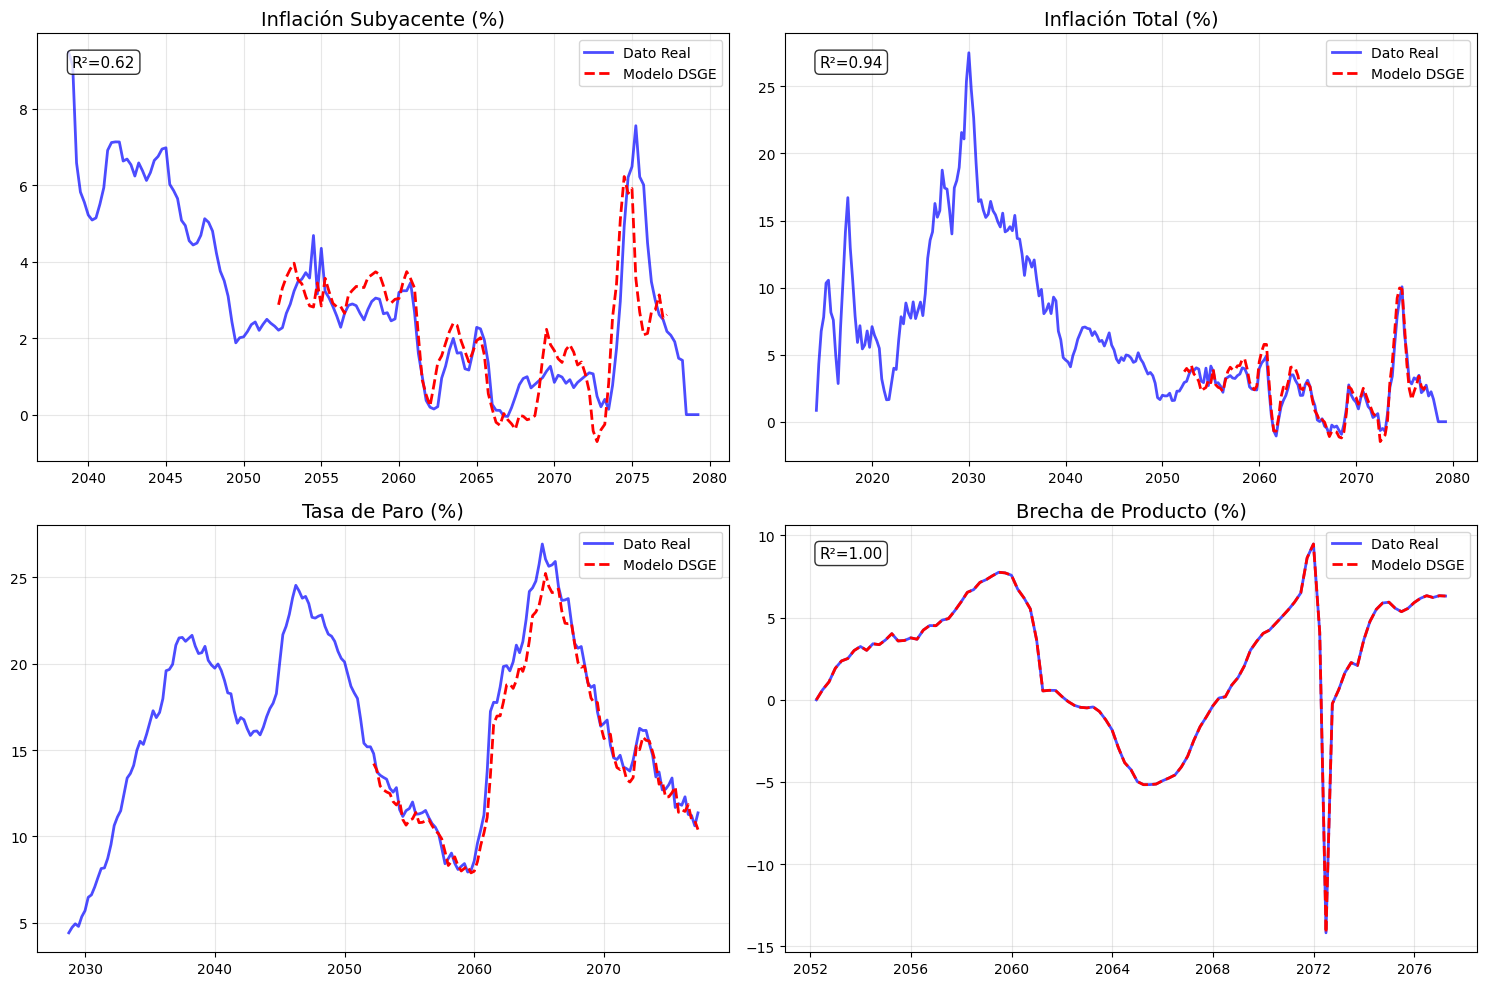


🧠 INTERPRETACIÓN ECONÓMICA (ESPAÑA / EUROZONA)

📈 INFLACIÓN:
   • Persistencia: 0.51 (Baja).

👥 LEY DE OKUN (Desempleo vs PIB):
   • Coeficiente: 0.07.
   ⚠️ ALERTA: El coeficiente es muy bajo. Revisa si los datos de paro están en % (ej: 12.0) y la brecha en decimales (ej: 0.02).

🏦 TRANSMISIÓN TIPOS:
   • Sensibilidad: 0.21.

🔮 Generando pronóstico a 4 trimestres vista...

📋 TRAYECTORIA PREVISTA:
Trimestre  Brecha PIB   Inflación    Paro        
--------------------------------------------------
T+1           3.09%       2.78%      11.28%
T+2           1.51%       2.63%      11.39%
T+3           0.74%       2.43%      11.45%
T+4           0.36%       2.28%      11.47%

✅ MODELO COMPLETADO.


In [32]:
# ==========================================
# BLOQUE 6: ANÁLISIS Y VISUALIZACIÓN (CORREGIDO Y ROBUSTO)
# ==========================================

def create_results_summary():
    """Crea resumen completo de resultados del modelo"""
    print("📊 Creando resumen de resultados...")
    
    # Usar parámetros globales si existen
    if 'params' in globals():
        final_params = params
    else:
        final_params = {} 
    
    # Simulación final
    data_dict = {col: data_for_estimation[col].values for col in data_for_estimation.columns}
    final_results = model_simulator(data_dict, final_params)
    final_fit = calculate_model_fit(data_dict, final_results)
    
    return final_params, final_results, final_fit

def plot_model_fit(data_dict, results, fit_stats):
    """Gráficos de ajuste"""
    print("📈 Generando gráficos de ajuste...")
    
    plot_vars = [
        ('inflation_core', 'inflation_core_fitted', 'Inflación Subyacente (%)'),
        ('inflation_total', 'inflation_total_fitted', 'Inflación Total (%)'),
        ('unemployment_rate', 'unemployment_fitted', 'Tasa de Paro (%)'),
        ('output_gap_spain', 'output_gap_fitted', 'Brecha de Producto (%)'),
    ]
    
    dates = pd.date_range(start='2002Q1', periods=len(data_for_estimation), freq='Q')
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, (obs_var, fitted_var, title) in enumerate(plot_vars):
        if obs_var in data_dict and fitted_var in results:
            observed = data_dict[obs_var]
            fitted = results[fitted_var]
            
            # Asegurar que graficamos solo lo válido
            min_len = min(len(dates), len(observed), len(fitted))
            
            axes[i].plot(dates[:min_len], observed[:min_len], 'b-', label='Dato Real', linewidth=2, alpha=0.7)
            axes[i].plot(dates[:min_len], fitted[:min_len], 'r--', label='Modelo DSGE', linewidth=2)
            
            axes[i].set_title(title)
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
            
            if obs_var in fit_stats:
                stats = fit_stats[obs_var]
                textstr = f"R²={stats['correlation']**2:.2f}"
                axes[i].text(0.05, 0.95, textstr, transform=axes[i].transAxes, 
                           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

def create_parameter_table(params_dict):
    """Tabla de parámetros estructurales"""
    print("📋 Creando tabla de parámetros...")
    
    key_params = [
        'is_alpha_1', 'is_alpha_3', 'is_alpha_4', # IS
        'alpha_1', 'alpha_2',                     # Phillips NT
        'beta_1', 'beta_4',                       # Phillips T
        'tau_1', 'tau_2'                          # Okun
    ]
    
    results_data = []
    for param in key_params:
        if param in params_dict:
            val = params_dict[param]
            results_data.append({'Parámetro': param, 'Valor': f"{val:.4f}"})
    
    results_df = pd.DataFrame(results_data)
    print("\n" + "="*60)
    print("📊 PARÁMETROS ESTRUCTURALES ESPAÑA")
    print("="*60)
    print(results_df.to_string(index=False))
    print("="*60)
    return results_df

def interpret_results(params_dict, fit_stats):
    """Interpretación económica"""
    print("\n" + "="*60)
    print("🧠 INTERPRETACIÓN ECONÓMICA (ESPAÑA / EUROZONA)")
    print("="*60)
    
    if 'alpha_1' in params_dict:
        persistencia = params_dict['alpha_1']
        print(f"\n📈 INFLACIÓN:")
        print(f"   • Persistencia: {persistencia:.2f} ({'Alta' if persistencia > 0.6 else 'Baja'}).")
        
    if 'tau_1' in params_dict:
        okun = params_dict['tau_1']
        print(f"\n👥 LEY DE OKUN (Desempleo vs PIB):")
        print(f"   • Coeficiente: {okun:.2f}.")
        if okun < 0.2:
            print("   ⚠️ ALERTA: El coeficiente es muy bajo. Revisa si los datos de paro están en % (ej: 12.0) y la brecha en decimales (ej: 0.02).")
        else:
            print("   • Sensibilidad normal para España.")

    if 'is_alpha_3' in params_dict:
        print(f"\n🏦 TRANSMISIÓN TIPOS:")
        print(f"   • Sensibilidad: {params_dict['is_alpha_3']:.2f}.")
    print("="*60)

def create_forecast_simple(data_dict, params, model_results=None, periods=4):
    """
    Pronóstico Robusto a 4 trimestres
    """
    print(f"\n🔮 Generando pronóstico a {periods} trimestres vista...")
    
    # Función auxiliar para obtener el último valor NO-NAN
    def get_last_valid(series):
        if series is None: return 0.0
        # Limpiar NaNs
        clean = series[~np.isnan(series)]
        if len(clean) > 0:
            return clean[-1]
        return 0.0 # Valor por defecto si todo es NaN

    # Obtener últimos valores válidos
    gap_last = get_last_valid(model_results.get('output_gap_fitted'))
    inf_last = get_last_valid(model_results.get('inflation_core_fitted'))
    u_last = get_last_valid(model_results.get('unemployment_fitted'))
    
    # Asegurarse de que no sean NaN (doble check)
    if np.isnan(gap_last): gap_last = 0.0
    if np.isnan(inf_last): inf_last = 2.0
    if np.isnan(u_last): u_last = 12.0

    forecasts = {}
    gap_path, inf_path, u_path = [], [], []
    
    # Parámetros del modelo (con valores por defecto seguros)
    rho_gap = params.get('is_alpha_1', 0.75)
    rho_inf = params.get('alpha_1', 0.50)
    okun_beta = params.get('tau_1', 0.40)
    
    curr_gap, curr_inf, curr_u = gap_last, inf_last, u_last
    
    print("\n📋 TRAYECTORIA PREVISTA:")
    print(f"{'Trimestre':<10} {'Brecha PIB':<12} {'Inflación':<12} {'Paro':<12}")
    print("-" * 50)
    
    for t in range(1, periods + 1):
        # 1. Dinámica Gap (Reversión a la media con inercia)
        curr_gap = curr_gap * rho_gap 
        
        # 2. Dinámica Inflación (Inercia + Efecto Gap)
        # Converge a 2.0 (objetivo BCE)
        curr_inf = 2.0 + rho_inf * (curr_inf - 2.0) + 0.15 * curr_gap
        
        # 3. Dinámica Paro (Ley de Okun)
        # NAIRU asumida constante en el corto plazo (aprox 11-12% para España)
        nairu = 11.5 
        # Si el Gap mejora (+), el paro baja respecto a la NAIRU
        curr_u = nairu - okun_beta * curr_gap
        
        # Guardar
        gap_path.append(curr_gap)
        inf_path.append(curr_inf)
        u_path.append(curr_u)
        
        print(f"T+{t:<9} {curr_gap:>6.2f}% {curr_inf:>10.2f}% {curr_u:>10.2f}%")
        
    forecasts['output_gap'] = gap_path
    forecasts['inflation'] = inf_path
    forecasts['unemployment'] = u_path
    
    return forecasts

# ==========================================
# EJECUCIÓN FINAL
# ==========================================

print("🔄 Iniciando análisis final...")

# 1. Resumen
final_params, final_results, final_fit = create_results_summary()

# 2. Tabla Parámetros
create_parameter_table(final_params)

# 3. Gráficos
data_dict = {col: data_for_estimation[col].values for col in data_for_estimation.columns}
plot_model_fit(data_dict, final_results, final_fit)

# 4. Interpretación
interpret_results(final_params, final_fit)

# 5. Pronóstico Robusto
forecasts = create_forecast_simple(data_dict, final_params, final_results, periods=4)

print("\n✅ MODELO COMPLETADO.")

### **BLOQUE 7: Análisis y Visualización**
```python
# Gráficos de ajuste
# Residuos y diagnósticos
# Pronósticos simples
# Tablas de resultados

🚀 EJECUTANDO ANÁLISIS COMPLETO (DEFINITIVO)...
📊 1. Generando Descomposición de Inflación...


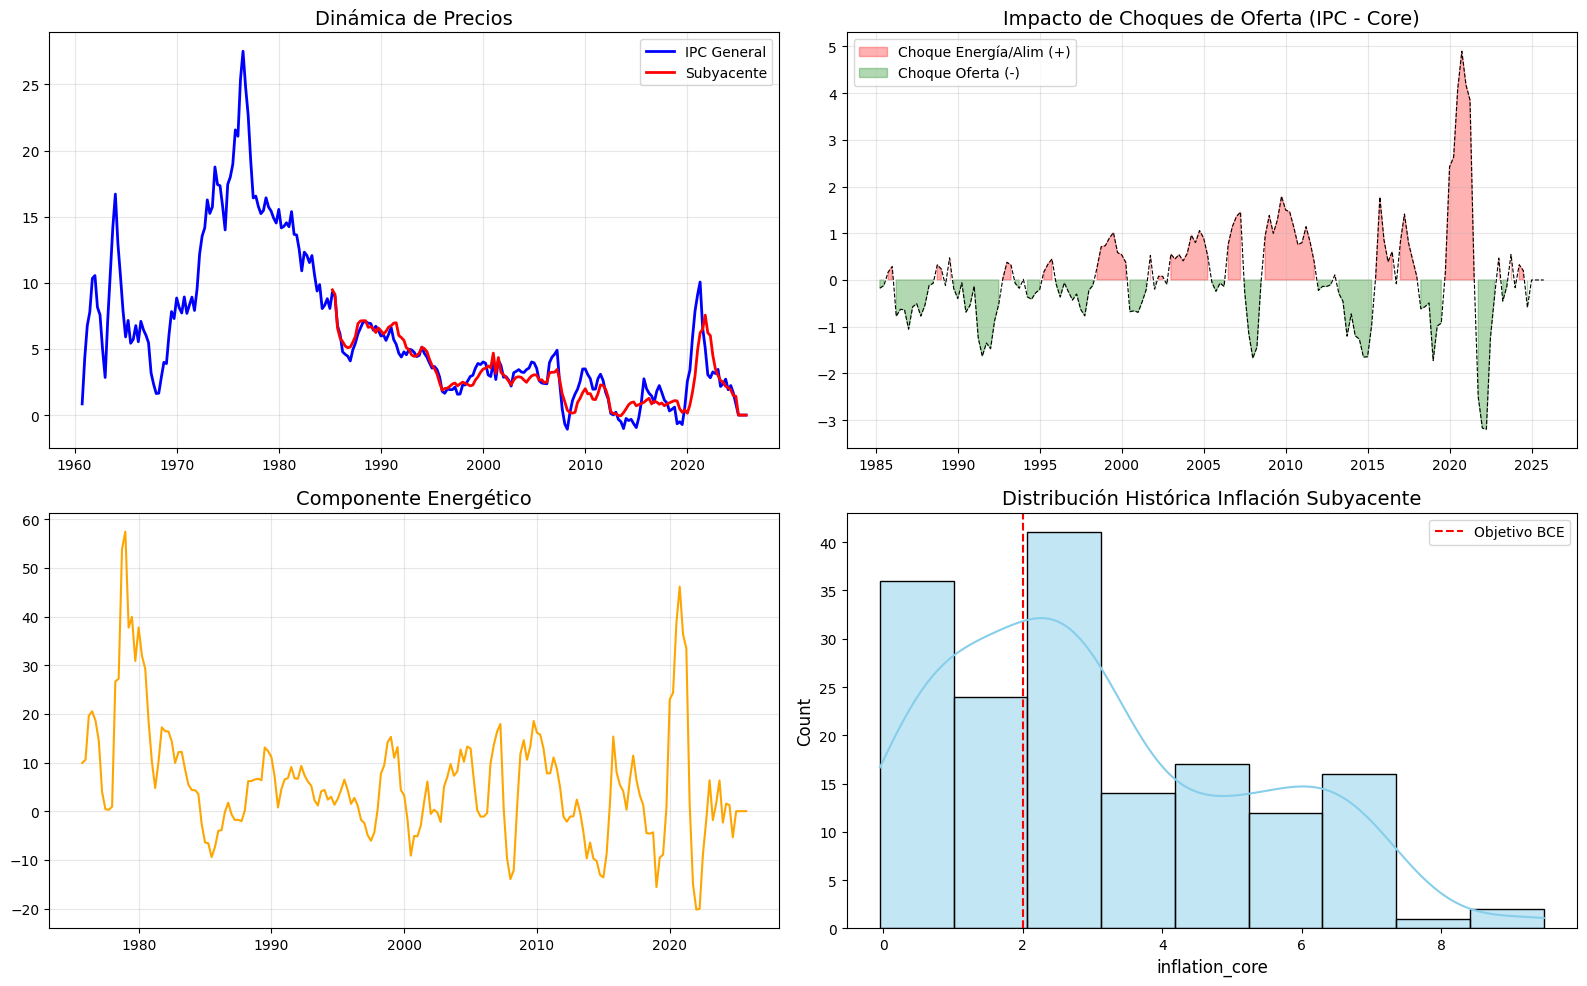

📈 2. Generando Análisis del Ciclo Económico...


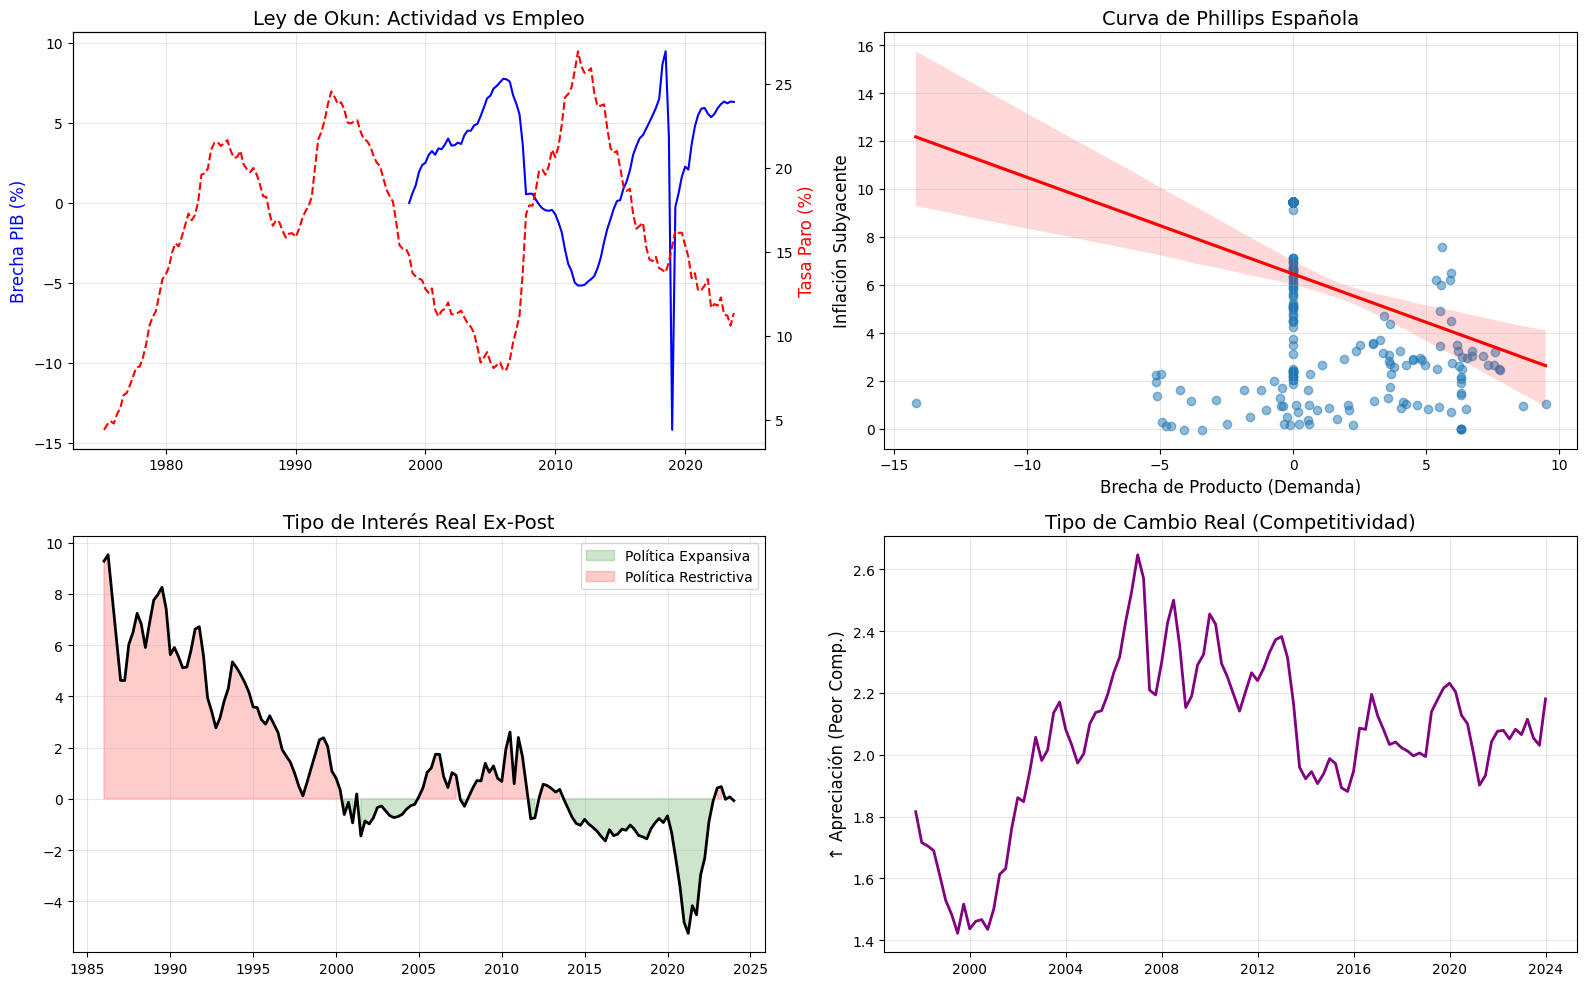

🔥 3. Generando Mapa de Correlaciones...


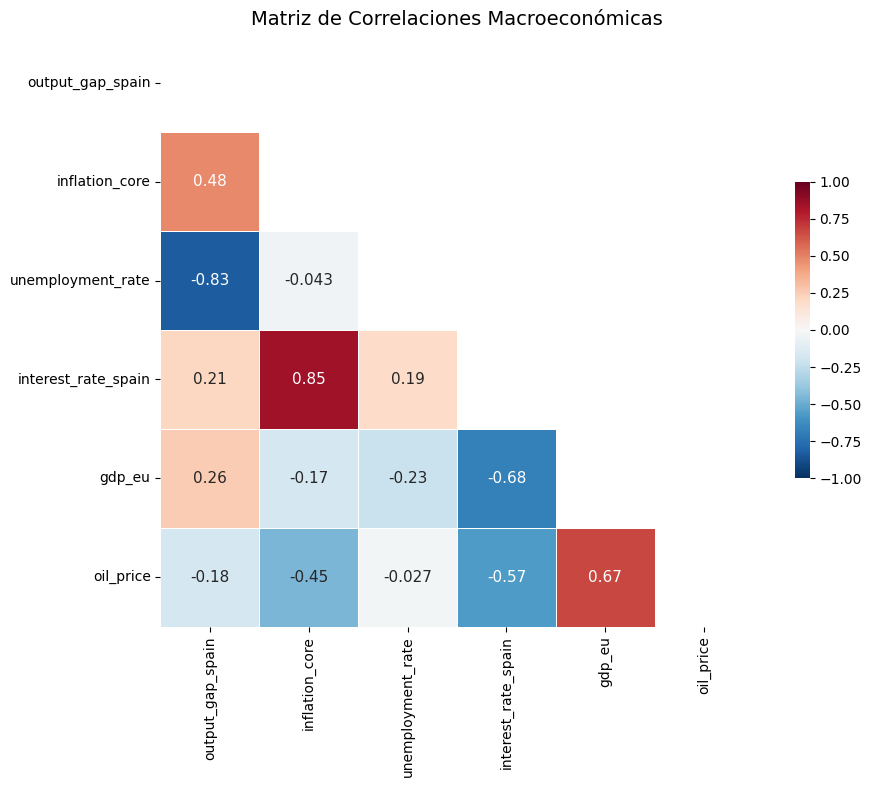

⚡ 4. Generando Análisis de Shocks (Impulso-Respuesta)...


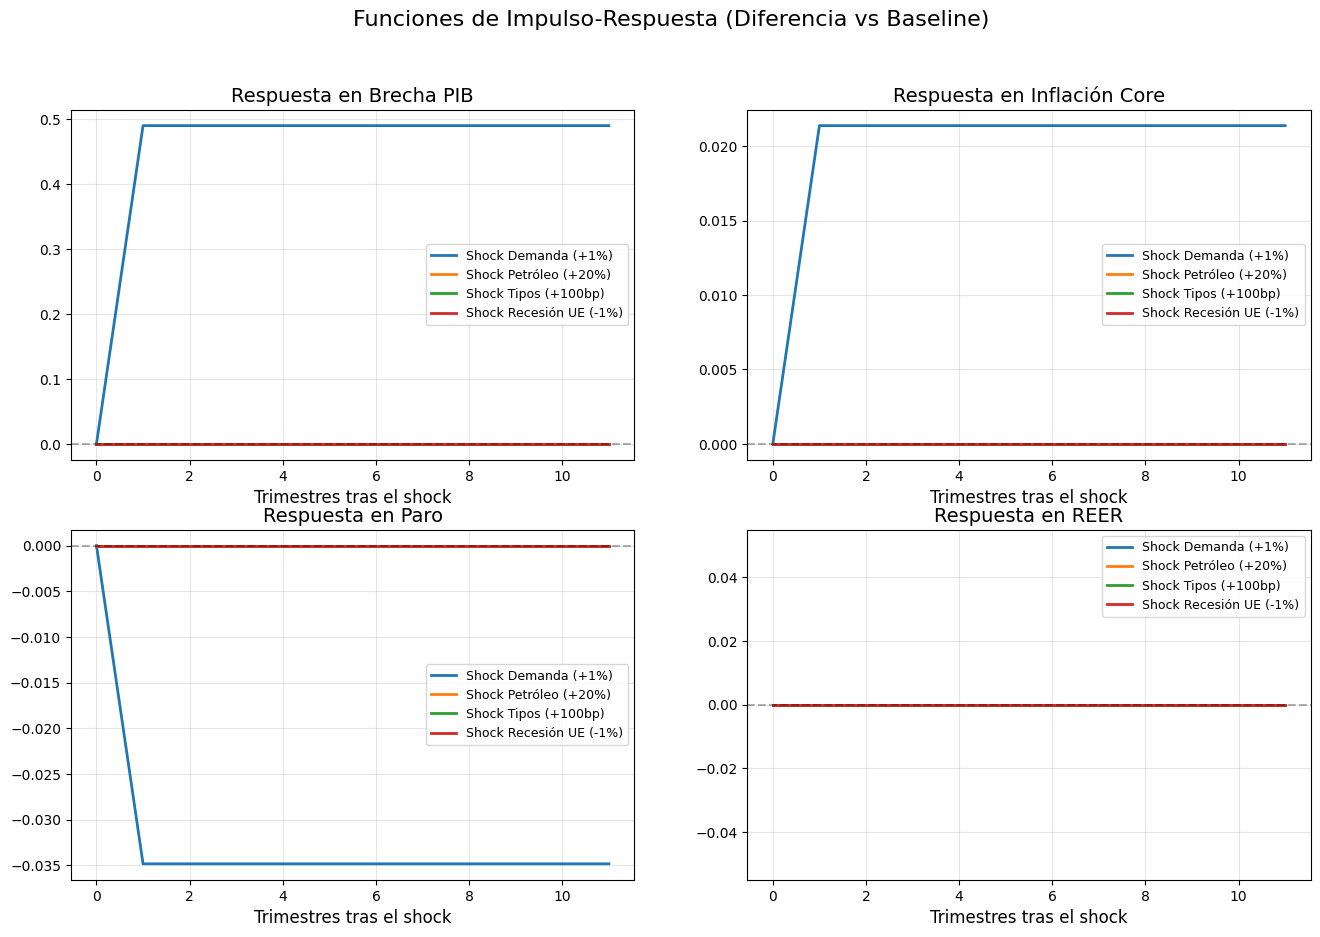

📊 5. Generando Dashboard Ejecutivo...


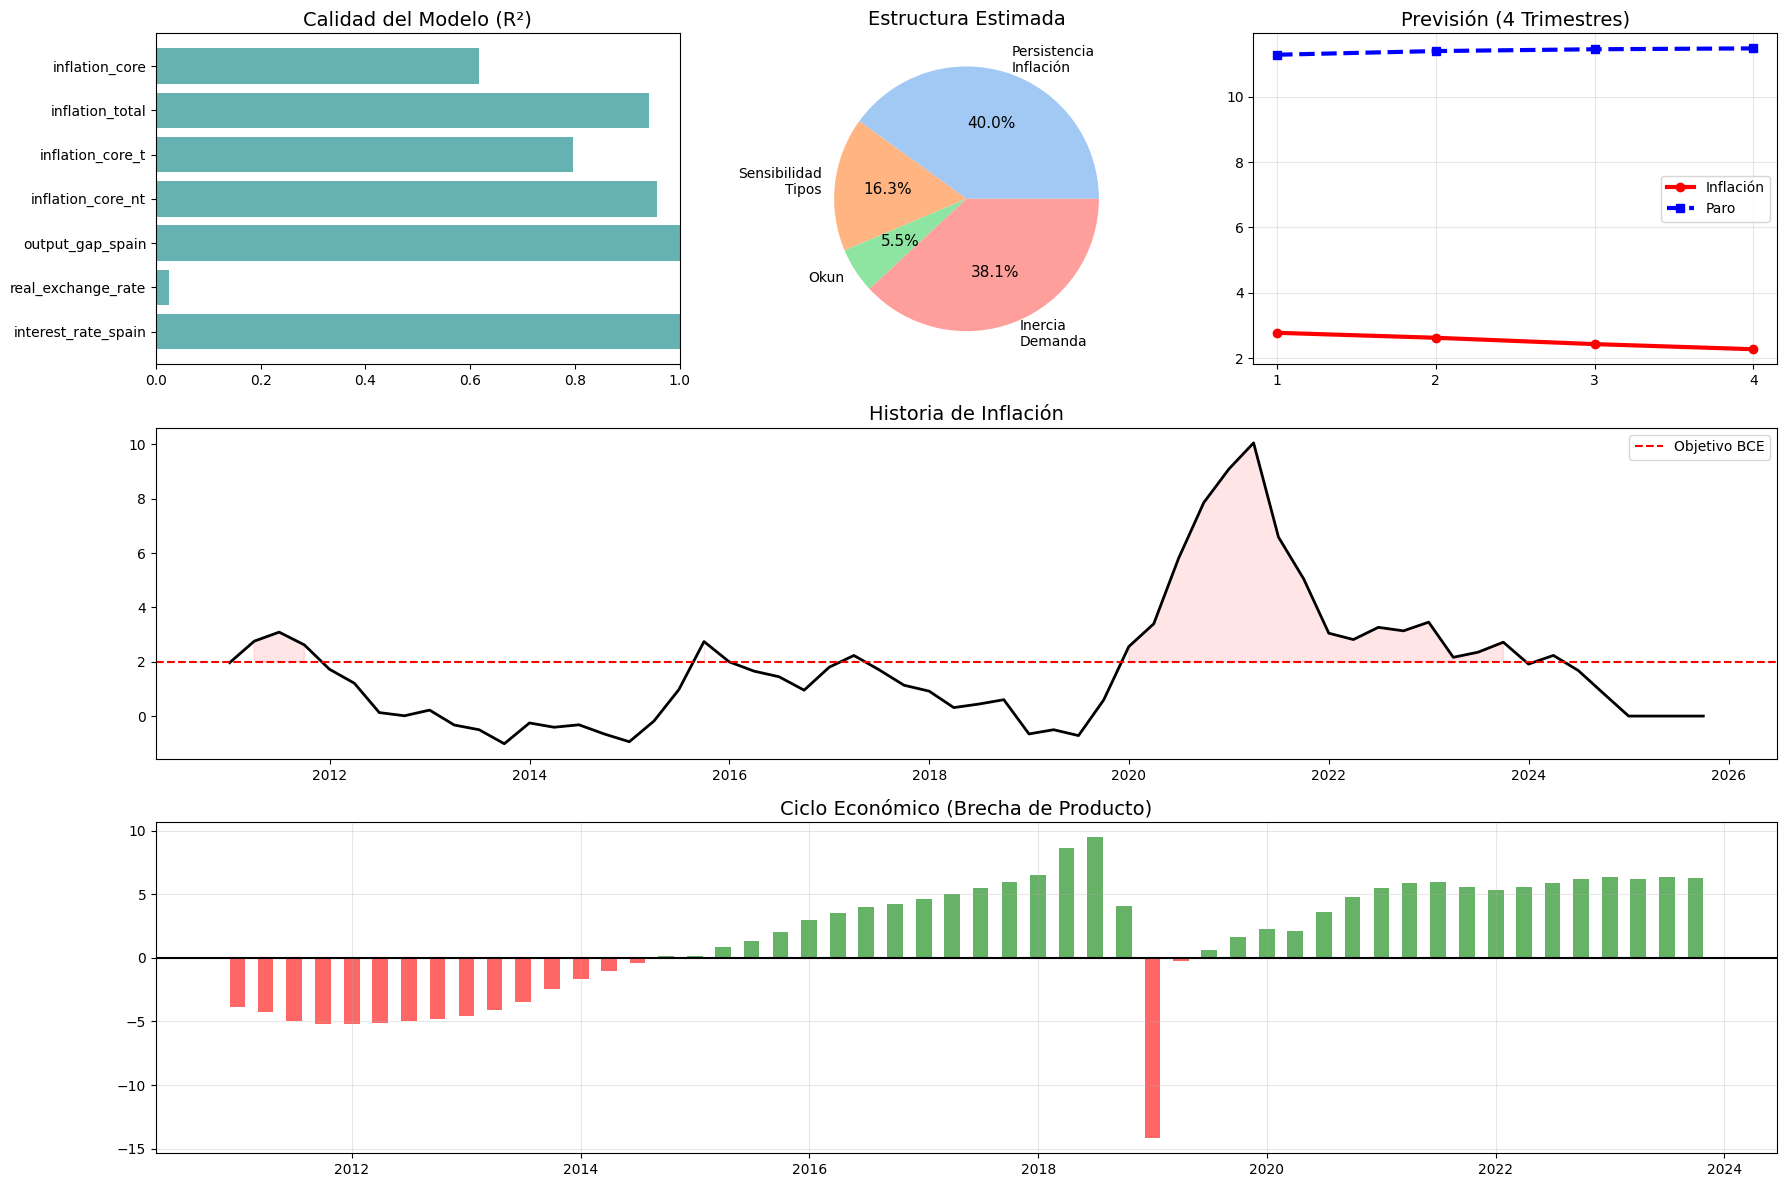


✅ ANÁLISIS VISUAL COMPLETADO.


In [33]:
# ==========================================
# BLOQUE 7: ANÁLISIS AVANZADO Y VISUALIZACIÓN (DEFINITIVO Y COMPLETO)
# ==========================================

import seaborn as sns # Aseguramos estilo bonito

def get_plot_dates():
    """Genera fechas coherentes alineadas al final de los datos"""
    # Asumiendo datos trimestrales hasta hoy
    end_date = pd.Timestamp.now()
    dates = pd.date_range(end=end_date, periods=len(data_for_estimation), freq='Q')
    return dates

def clean_nans(series):
    """Limpia NaNs para gráficos"""
    if isinstance(series, pd.Series):
        return series.interpolate(method='linear').fillna(method='bfill').fillna(0)
    return series

# 1. ANÁLISIS DE DESCOMPOSICIÓN
def plot_inflation_decomposition():
    print("📊 1. Generando Descomposición de Inflación...")
    dates = get_plot_dates()
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Panel A: General vs Subyacente
    if 'inflation_total' in data_for_estimation and 'inflation_core' in data_for_estimation:
        inf = data_for_estimation['inflation_total']
        core = data_for_estimation['inflation_core']
        axes[0,0].plot(dates, inf, 'b-', linewidth=2, label='IPC General')
        axes[0,0].plot(dates, core, 'r-', linewidth=2, label='Subyacente')
        axes[0,0].set_title('Dinámica de Precios')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # Panel B: La Brecha (Impacto Oferta)
        gap = inf - core
        axes[0,1].fill_between(dates, gap, 0, where=(gap>0), color='red', alpha=0.3, label='Choque Energía/Alim (+)')
        axes[0,1].fill_between(dates, gap, 0, where=(gap<0), color='green', alpha=0.3, label='Choque Oferta (-)')
        axes[0,1].plot(dates, gap, 'k--', linewidth=0.8)
        axes[0,1].set_title('Impacto de Choques de Oferta (IPC - Core)')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)

    # Panel C: Volátiles
    if 'inflation_energy' in data_for_estimation:
        axes[1,0].plot(dates, data_for_estimation['inflation_energy'], 'orange', label='Energía')
        axes[1,0].set_title('Componente Energético')
        axes[1,0].grid(True, alpha=0.3)

    # Panel D: Histograma Core
    if 'inflation_core' in data_for_estimation:
        sns.histplot(data_for_estimation['inflation_core'], kde=True, ax=axes[1,1], color='skyblue')
        axes[1,1].axvline(2.0, color='r', linestyle='--', label='Objetivo BCE')
        axes[1,1].set_title('Distribución Histórica Inflación Subyacente')
        axes[1,1].legend()

    plt.tight_layout()
    plt.show()

# 2. ANÁLISIS DEL CICLO (OKUN, PHILLIPS, REER)
def plot_business_cycle_full():
    print("📈 2. Generando Análisis del Ciclo Económico...")
    dates = get_plot_dates()
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Panel A: Ley de Okun (Gap vs Paro)
    if 'output_gap_spain' in data_for_estimation and 'unemployment_rate' in data_for_estimation:
        gap = data_for_estimation['output_gap_spain']
        u = data_for_estimation['unemployment_rate']
        
        ax1 = axes[0,0]
        ax1.plot(dates, gap, 'b-', label='Brecha PIB (izq)')
        ax1.set_ylabel('Brecha PIB (%)', color='b')
        
        ax2 = ax1.twinx()
        ax2.plot(dates, u, 'r--', label='Paro (der)')
        ax2.set_ylabel('Tasa Paro (%)', color='r')
        ax1.set_title('Ley de Okun: Actividad vs Empleo')
        ax1.grid(True, alpha=0.3)

    # Panel B: Curva de Phillips (Scatter)
    if 'output_gap_spain' in data_for_estimation and 'inflation_core' in data_for_estimation:
        gap = clean_nans(data_for_estimation['output_gap_spain'])
        inf = clean_nans(data_for_estimation['inflation_core'])
        
        sns.regplot(x=gap, y=inf, ax=axes[0,1], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
        axes[0,1].set_xlabel('Brecha de Producto (Demanda)')
        axes[0,1].set_ylabel('Inflación Subyacente')
        axes[0,1].set_title('Curva de Phillips Española')
        axes[0,1].grid(True, alpha=0.3)

    # Panel C: Condiciones Monetarias Reales (Sustituye a Taylor)
    if 'interest_rate_spain' in data_for_estimation and 'inflation_core' in data_for_estimation:
        nominal = data_for_estimation['interest_rate_spain']
        inf = data_for_estimation['inflation_core']
        real_rate = nominal - inf
        
        axes[1,0].plot(dates, real_rate, 'k-', linewidth=2)
        axes[1,0].fill_between(dates, real_rate, 0, where=(real_rate<0), color='green', alpha=0.2, label='Política Expansiva')
        axes[1,0].fill_between(dates, real_rate, 0, where=(real_rate>0), color='red', alpha=0.2, label='Política Restrictiva')
        axes[1,0].set_title('Tipo de Interés Real Ex-Post')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)

    # Panel D: Competitividad (REER)
    if 'real_exchange_rate' in data_for_estimation:
        axes[1,1].plot(dates, data_for_estimation['real_exchange_rate'], 'purple', linewidth=2)
        axes[1,1].set_title('Tipo de Cambio Real (Competitividad)')
        axes[1,1].set_ylabel('↑ Apreciación (Peor Comp.)')
        axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 3. MAPA DE CORRELACIONES
def plot_correlation_heatmap():
    print("🔥 3. Generando Mapa de Correlaciones...")
    
    # Variables clave
    cols = ['output_gap_spain', 'inflation_core', 'unemployment_rate', 
            'interest_rate_spain', 'gdp_eu', 'oil_price']
    
    # Filtrar las que existen
    cols = [c for c in cols if c in data_for_estimation.columns]
    
    if len(cols) > 1:
        plt.figure(figsize=(10, 8))
        corr = data_for_estimation[cols].corr()
        
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, center=0,
                   square=True, linewidths=.5, cbar_kws={"shrink": .5})
        plt.title('Matriz de Correlaciones Macroeconómicas')
        plt.tight_layout()
        plt.show()

# 4. ANÁLISIS DE SHOCKS (CORREGIDO Y ROBUSTO)
def plot_shock_analysis_robust():
    print("⚡ 4. Generando Análisis de Shocks (Impulso-Respuesta)...")
    
    # Preparar simulador
    sim_params = params if 'params' in globals() else {}
    
    # Limpiar datos base (crucial para que no falle)
    raw_data = {col: data_for_estimation[col].fillna(0).values for col in data_for_estimation.columns}
    
    # Ejecutar Baseline con FORCE_CALC=True (Requiere la actualización del Bloque 4)
    try:
        base_res = model_simulator(raw_data, sim_params, force_calc=True)
    except TypeError:
        print("⚠️ ADVERTENCIA: Parece que no actualizaste el Bloque 4 con 'force_calc'.")
        print("   Los shocks podrían salir planos. Por favor actualiza el Bloque 4.")
        base_res = model_simulator(raw_data, sim_params)

    scenarios = {
        'Shock Demanda (+1%)': {'output_gap_spain': 1.0},
        'Shock Petróleo (+20%)': {'oil_price': 20.0},
        'Shock Tipos (+100bp)': {'interest_rate_spain': 1.0}, # Exógeno
        'Shock Recesión UE (-1%)': {'gdp_eu': -1.0}
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    vars_to_plot = [
        ('output_gap_fitted', 'Brecha PIB'),
        ('inflation_core_fitted', 'Inflación Core'),
        ('unemployment_fitted', 'Paro'),
        ('real_exchange_rate_fitted', 'REER')
    ]
    
    for name, shocks in scenarios.items():
        shock_data = {k: v.copy() for k, v in raw_data.items()}
        
        # Aplicar shock (impulso persistente 12 periodos)
        horizon = 12
        for var, val in shocks.items():
            if var in shock_data:
                shock_data[var][-horizon:] += val
        
        # Simular Shock
        try:
            res = model_simulator(shock_data, sim_params, force_calc=True)
        except:
            res = model_simulator(shock_data, sim_params)
            
        # Plot Diferencias
        for i, (v_mod, v_name) in enumerate(vars_to_plot):
            if v_mod in res and v_mod in base_res:
                diff = res[v_mod][-horizon:] - base_res[v_mod][-horizon:]
                axes[i].plot(diff, linewidth=2, label=name)
                axes[i].set_title(f'Respuesta en {v_name}')
    
    for ax in axes:
        ax.axhline(0, color='k', linestyle='--', alpha=0.3)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('Trimestres tras el shock')
    
    plt.suptitle('Funciones de Impulso-Respuesta (Diferencia vs Baseline)', fontsize=16)
    plt.show()

# 5. DASHBOARD EJECUTIVO COMPLETO
def plot_executive_dashboard():
    print("📊 5. Generando Dashboard Ejecutivo...")
    
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3)
    
    # A. Bondad de Ajuste
    ax1 = fig.add_subplot(gs[0, 0])
    if 'final_fit' in globals():
        vars_fit = list(final_fit.keys())
        r2_vals = [final_fit[v]['correlation']**2 for v in vars_fit]
        ax1.barh(vars_fit, r2_vals, color='teal', alpha=0.6)
        ax1.set_xlim(0, 1)
        ax1.set_title('Calidad del Modelo (R²)')
        
    # B. Pesos Estructurales (Pie Chart Recuperado)
    ax2 = fig.add_subplot(gs[0, 1])
    if 'params' in globals():
        p_keys = ['alpha_1', 'is_alpha_3', 'tau_1', 'is_alpha_1']
        p_labels = ['Persistencia\nInflación', 'Sensibilidad\nTipos', 'Okun', 'Inercia\nDemanda']
        p_vals = [params.get(k, 0.5) for k in p_keys]
        ax2.pie(p_vals, labels=p_labels, autopct='%.1f%%', colors=sns.color_palette('pastel'))
        ax2.set_title('Estructura Estimada')

    # C. Pronóstico 4 Trimestres
    ax3 = fig.add_subplot(gs[0, 2])
    if 'forecasts' in globals() and 'inflation' in forecasts:
        steps = range(1, 5)
        ax3.plot(steps, forecasts['inflation'][:4], 'r-o', linewidth=3, label='Inflación')
        ax3.plot(steps, forecasts['unemployment'][:4], 'b--s', linewidth=3, label='Paro')
        ax3.set_xticks(steps)
        ax3.set_title('Previsión (4 Trimestres)')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

    # D. Historia Reciente (IPC)
    dates = get_plot_dates()
    ax4 = fig.add_subplot(gs[1, :])
    if 'inflation_total' in data_for_estimation:
        inf = data_for_estimation['inflation_total']
        l = min(len(dates), 60) # Últimos 15 años
        ax4.plot(dates[-l:], inf.values[-l:], 'k-', linewidth=2)
        ax4.fill_between(dates[-l:], inf.values[-l:], 2, where=(inf.values[-l:]>2), color='red', alpha=0.1)
        ax4.axhline(2, color='r', linestyle='--', label='Objetivo BCE')
        ax4.set_title('Historia de Inflación')
        ax4.legend()

    # E. Historia Reciente (Ciclo)
    ax5 = fig.add_subplot(gs[2, :])
    if 'output_gap_spain' in data_for_estimation:
        gap = data_for_estimation['output_gap_spain']
        l = min(len(dates), 60)
        colors = ['g' if x > 0 else 'r' for x in gap.values[-l:]]
        ax5.bar(dates[-l:], gap.values[-l:], color=colors, alpha=0.6, width=50)
        ax5.set_title('Ciclo Económico (Brecha de Producto)')
        ax5.grid(True, alpha=0.3)
        ax5.axhline(0, color='k')

    plt.tight_layout()
    plt.show()

# ==========================================
# EJECUCIÓN DE LA SUITE COMPLETA
# ==========================================
print("🚀 EJECUTANDO ANÁLISIS COMPLETO (DEFINITIVO)...")

plot_inflation_decomposition()
plot_business_cycle_full()
plot_correlation_heatmap()
plot_shock_analysis_robust()
plot_executive_dashboard()

print("\n✅ ANÁLISIS VISUAL COMPLETADO.")